In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.dates import DateFormatter
from scipy.signal import find_peaks
from collections import Counter


# Pipeline

## Pré tratamento

In [ ]:
#carregando dados
#Na i246 os sensores estão invertidos, logo outside = inside e inside = outside
name = 'exp4_e3'
data = pd.read_csv('exps/exp4-22-07/ev3.csv')
backup_data = data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   228 non-null    int64  
 1   distance_cm_inside   228 non-null    float64
 2   distance_cm_outside  228 non-null    float64
 3   measured_at          228 non-null    object 
 4   epoch_start          228 non-null    float64
 5   epoch_end            228 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 10.8+ KB
None


In [470]:
data["measured_at"] = data["measured_at"].astype(str)

In [471]:
data["minute"] = data["measured_at"].str[14:16].astype(int)  # Extrai os minutos
data["second"] = data["measured_at"].str[17:19].astype(int)  # Extrai os segundos
data["millisecond"] = data["measured_at"].str[20:].fillna("0").replace("", "0").astype(int)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   228 non-null    int64  
 1   distance_cm_inside   228 non-null    float64
 2   distance_cm_outside  228 non-null    float64
 3   measured_at          228 non-null    object 
 4   epoch_start          228 non-null    float64
 5   epoch_end            228 non-null    float64
 6   minute               228 non-null    int64  
 7   second               228 non-null    int64  
 8   millisecond          228 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 16.2+ KB
None


In [472]:
print(data[data.isna().any(axis=1)])


Empty DataFrame
Columns: [id, distance_cm_inside, distance_cm_outside, measured_at, epoch_start, epoch_end, minute, second, millisecond]
Index: []


In [473]:
data['measured_at'] = (data["minute"].astype(int) * 60 * 1000) + (data["second"].astype(int) * 1000) + data["millisecond"].astype(int)
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond
0,231900333,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19
1,231900334,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65
2,231900335,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111
3,231900336,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157
4,231900337,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203
...,...,...,...,...,...,...,...,...,...
223,231900556,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766
224,231900557,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823
225,231900558,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880
226,231900559,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938


In [474]:
#data['measured_at'] = pd.to_datetime(data['measured_at'], errors='coerce')
#data


In [475]:
print(data[data.isna().any(axis=1)])

Empty DataFrame
Columns: [id, distance_cm_inside, distance_cm_outside, measured_at, epoch_start, epoch_end, minute, second, millisecond]
Index: []


In [476]:
#Reograniza os índices
data['id'] = data.index + 1
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203
...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938


## Visualização sem colorização por estados

In [477]:
data['soma_distancias_cm'] = data['distance_cm_inside'] + data['distance_cm_outside']
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19,200.0
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65,200.0
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111,200.0
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157,201.0
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203,200.0
...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0


Este plot apresenta a distribuição das leituras, pode-se ver uma incidência dos pontos através do quão opaco o ponto é plotado, tendo em vista que a opacidade de apenas um ponto é de 0.5. Logo utiliza-se este gráfico para melhor visualizar as medidas capturadas pelo sensor e seu comportamento.

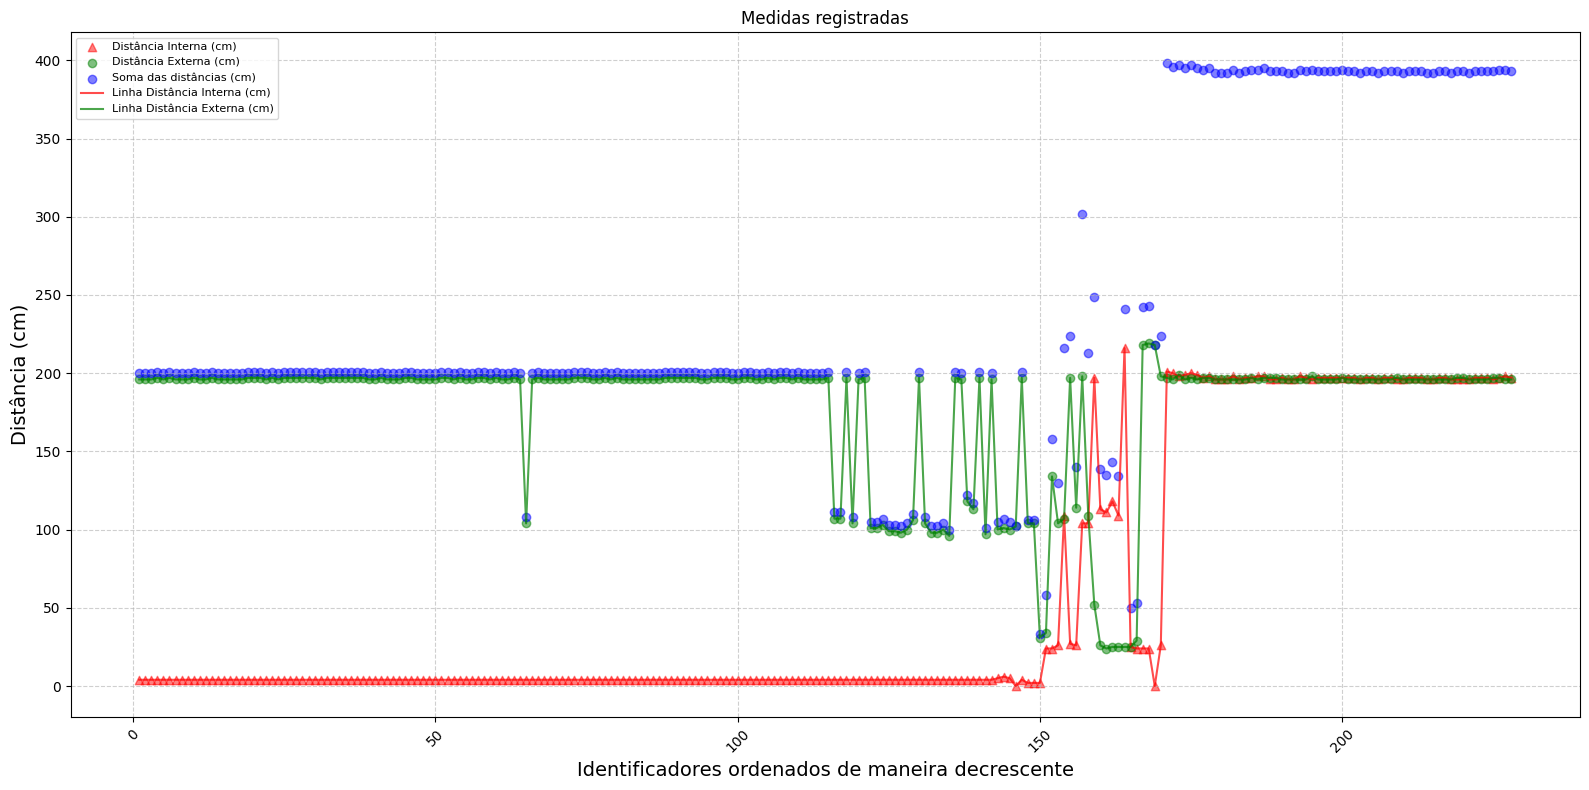

In [478]:
import matplotlib.pyplot as plt

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com transparência para evitar sobreposição
plt.scatter(data['id'], data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c='red')
plt.scatter(data['id'], data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c='green')
plt.scatter(data['id'], data['soma_distancias_cm'], label='Soma das distâncias (cm)', alpha=0.5, c='blue')


plt.plot(data['id'], data['distance_cm_inside'], linestyle='-', color='red', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(data['id'], data['distance_cm_outside'], linestyle='-', color='green', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
#plt.title('Distâncias Interna e Externa por ID (SALA I-246)', fontsize=16)
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Medidas registradas')

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

filename = f"Dispersão_{name}.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
#Salvando o gráfico como PNG
plt.show()
plt.close()


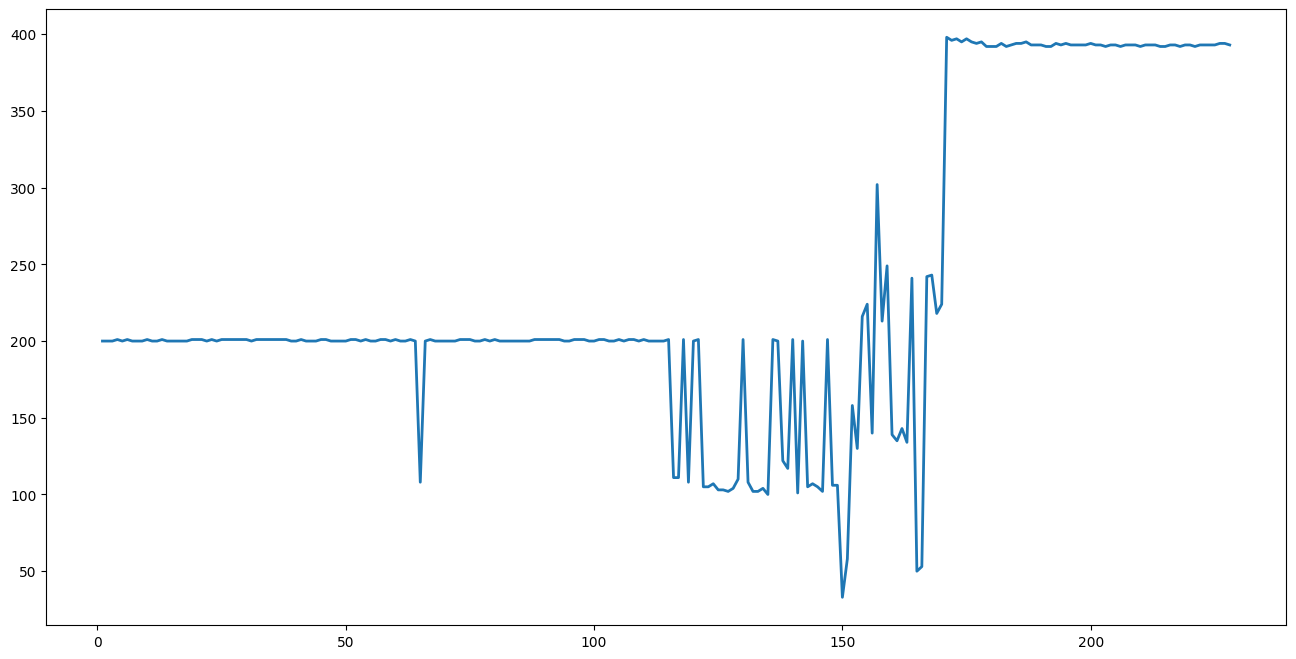

In [479]:
plt.figure(figsize=(16, 8))
#plt.plot(df['id'], df['distance_cm_inside'], label='y1 Original', alpha=0.5)
plt.plot(data['id'], data['soma_distancias_cm'], label='inside', linewidth=2)
#filename = f"WMA_{name}.png"

# Salvando o gráfico como PNG
#plt.gca().invert_yaxis()
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()




In [480]:
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19,200.0
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65,200.0
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111,200.0
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157,201.0
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203,200.0
...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0


## Processo de cálculo de médias

In [481]:
n = 21

In [482]:
backup_data = data
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19,200.0
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65,200.0
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111,200.0
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157,201.0
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203,200.0
...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0


In [483]:
import pandas as pd
import numpy as np

def geometric_mean(series):
    return np.exp(np.log(series).mean())

# Calculando a média geométrica de n em 5 linhas

geometric_means_list = []
for i in range(0, len(backup_data), n):
    df_subset = backup_data.iloc[i:i+n]
    geometric_means = df_subset.select_dtypes(include=[np.number]).apply(geometric_mean)
    geometric_means_list.append(geometric_means)

# Criando um DataFrame com os resultados
geometric_means_df = pd.DataFrame(geometric_means_list)

# Exibindo os resultados
geometric_means_df['id'] = geometric_means_df.index + 1
#geometric_means_df


/home/giron/work/exploring_raw_measures_data/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [484]:
backup_data = data
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19,200.0
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65,200.0
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111,200.0
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157,201.0
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203,200.0
...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0


In [485]:
import pandas as pd
import numpy as np

def quadratic_mean(series):
    return np.sqrt(np.mean(np.square(series)))

quadratic_means_list = []
for i in range(0, len(backup_data), n):
    df_subset = backup_data.iloc[i:i+n]
    quadratic_means = df_subset.select_dtypes(include=[np.number]).apply(quadratic_mean)
    quadratic_means_list.append(quadratic_means)

# Criando DataFrames com os resultados
quadratic_means_df = pd.DataFrame(quadratic_means_list)

# Exibindo os resultados
#print("Média Quadrática:")
quadratic_means_df['id'] = quadratic_means_df.index + 1
#quadratic_means_df


In [486]:
backup_data = data
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19,200.0
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65,200.0
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111,200.0
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157,201.0
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203,200.0
...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0


In [487]:
simple_mean = backup_data[['distance_cm_inside', 'distance_cm_outside']].groupby(np.arange(len(backup_data)) // n).mean()
simple_mean['id'] = simple_mean.index + 1
#simple_mean

In [488]:
backup_data = data
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19,200.0
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65,200.0
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111,200.0
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157,201.0
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203,200.0
...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0


In [489]:
backup_data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19,200.0
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65,200.0
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111,200.0
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157,201.0
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203,200.0
...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0


In [ ]:
df1 = backup_data

window_size = 21
poly_order = 2

df1['inside_smooth'] = savgol_filter(df1['distance_cm_inside'], window_size, poly_order)
df1['outside_smooth'] = savgol_filter(df1['distance_cm_outside'], window_size, poly_order)
df1['soma_smooth'] = savgol_filter(df1['soma_distancias_cm'], window_size, poly_order)

plt.figure(figsize=(16, 8))
#plt.plot(df1['id'], df1['distance_cm_inside'], label='y1 Original', alpha=0.5)
plt.plot(df1['id'], df1['inside_smooth'], label='inside', linewidth=2)
#plt.plot(df1['id'], df1['distance_cm_outside'], label='y2 Original', alpha=0.5)
plt.plot(df1['id'], df1['outside_smooth'], label='outside', linewidth=2)
plt.plot(df1['id'], df1['soma_smooth'], label='outside', linewidth=2)
plt.legend()
plt.title(f"SG_{name}")
filename = f"SG_{name}.png"

# Salvando o gráfico como PNG
#plt.gca().invert_yaxis()
plt.savefig(filename, dpi=300, bbox_inches='tight')
#plt.show()
plt.close()


In [491]:
import matplotlib.pyplot as plt

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com transparência para evitar sobreposição
plt.scatter(data['measured_at'], data['inside_smooth'], label='Distância Interna (cm)', alpha=0.5, marker='^', c='red')
plt.scatter(data['measured_at'], data['outside_smooth'], label='Distância Externa (cm)', alpha=0.5, c='green')

plt.plot(data['measured_at'], data['inside_smooth'], linestyle='-', color='red', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(data['measured_at'], data['outside_smooth'], linestyle='-', color='green', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
#plt.title('Distâncias Interna e Externa por ID (SALA I-246)', fontsize=16)
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Medidas registradas')

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

filename = f"Dispersão_{name}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
#plt.show()
plt.close()


In [492]:
data

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm,inside_smooth,outside_smooth,soma_smooth
0,1,4.0,196.0,1110019,1.753190e+09,1.753190e+09,18,30,19,200.0,4.000000,196.315641,200.315641
1,2,4.0,196.0,1110065,1.753190e+09,1.753190e+09,18,30,65,200.0,4.000000,196.279390,200.279390
2,3,4.0,196.0,1110111,1.753190e+09,1.753190e+09,18,30,111,200.0,4.000000,196.249143,200.249143
3,4,4.0,197.0,1110157,1.753190e+09,1.753190e+09,18,30,157,201.0,4.000000,196.224898,200.224898
4,5,4.0,196.0,1110203,1.753190e+09,1.753190e+09,18,30,203,200.0,4.000000,196.206657,200.206657
...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0,196.770692,196.307760,393.078451
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0,196.878570,196.328527,393.207097
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0,196.999049,196.350691,393.349740
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0,197.132129,196.374252,393.506381


In [493]:
def analyze_peaks_and_valleys(df, columns, prominence=3, distance=30):
    """
    Analisa picos e vales de múltiplas séries de dados em um DataFrame e classifica cada ponto.
    
    Parâmetros:
        df (pd.DataFrame): DataFrame contendo os dados.
        columns (list): Lista com os nomes das colunas a serem analisadas.
        prominence (float): Proeminência mínima para detectar picos.
        distance (int): Distância mínima entre os picos/vales.
    
    Retorna:
        pd.DataFrame: DataFrame atualizado com uma nova coluna de classificação para cada série analisada.
    """
    plt.figure(figsize=(12, 6))
    indices = np.arange(len(df))
    
    for column in columns:
        data = df[column].values
        
        # Encontrando picos
        peaks, _ = find_peaks(data, prominence=prominence, distance=distance)
        # Encontrando vales (inverter os dados para encontrar mínimos como máximos)
        valleys, _ = find_peaks(-data, prominence=prominence, distance=distance)
        
        # Criando nova coluna de classificação
        classification = np.full(len(data), "Nada", dtype=object)
        classification[peaks] = f"Pico {column}"
        classification[valleys] = f"Vale {column}"
        df[f'{column}_classification'] = classification
        
        # Plotando os resultados
        plt.plot(indices, data, label=f'{column}')
        plt.scatter(peaks, data[peaks], marker='^', label=f'Picos {column}')
        plt.scatter(valleys, data[valleys], marker='v', label=f'Vales {column}')
    
    plt.xlabel('Índice')
    plt.ylabel('Valor')
    plt.legend()
    plt.title('Picos e Vales das Séries')
    plt.show()
    
    return df

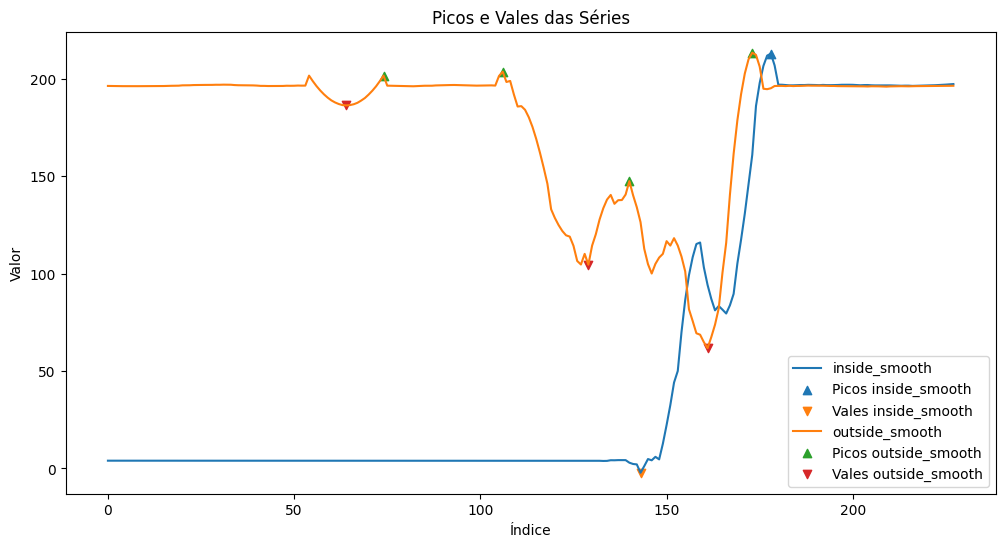

In [494]:
name_col = ["inside_smooth", "outside_smooth"]
df_resul = analyze_peaks_and_valleys(data, name_col)
#print("Picos encontrados nos índices:", peaks)
#print("Vales encontrados nos índices:", valleys)

In [495]:
df_resul = df_resul[(df_resul['inside_smooth_classification'] == 'Vale inside_smooth') | (df_resul['outside_smooth_classification'] == 'Vale outside_smooth') | (df_resul['outside_smooth_classification'] == 'Pico outside_smooth') | (df_resul['inside_smooth_classification'] == 'Pico inside_smooth')]

In [496]:
print(df_resul.info())
#df_resul

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 64 to 178
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             9 non-null      int64  
 1   distance_cm_inside             9 non-null      float64
 2   distance_cm_outside            9 non-null      float64
 3   measured_at                    9 non-null      int64  
 4   epoch_start                    9 non-null      float64
 5   epoch_end                      9 non-null      float64
 6   minute                         9 non-null      int64  
 7   second                         9 non-null      int64  
 8   millisecond                    9 non-null      int64  
 9   soma_distancias_cm             9 non-null      float64
 10  inside_smooth                  9 non-null      float64
 11  outside_smooth                 9 non-null      float64
 12  soma_smooth                    9 non-null      float64
 

In [497]:
def analyze_concavity_changes(df, columns):
    """
    Analisa as mudanças de concavidade em múltiplas séries de dados em um DataFrame.
    
    Parâmetros:
        df (pd.DataFrame): DataFrame contendo os dados.
        columns (list): Lista com os nomes das colunas a serem analisadas.
    
    Retorna:
        dict: Dicionário contendo os índices das mudanças de concavidade para cada coluna.
    """
    plt.figure(figsize=(12, 6))
    indices = np.arange(len(df))
    
    results = {}

    for column in columns:
        if column not in df.columns:
            print(f"A coluna '{column}' não existe no DataFrame. Ignorando.")
            continue
        
        data = df[column].values
        if data.ndim != 1:
            print(f"Erro: A coluna '{column}' não é unidimensional.")
            continue
        
        # Segunda derivada para encontrar mudanças de concavidade
        second_derivative = np.gradient(np.gradient(data))
        concavity_changes = np.where(np.diff(np.sign(second_derivative)) != 0)[0]
        
        # Armazena os resultados para cada coluna
        results[column] = {"mudanças_concavidade": concavity_changes}
        
        # Plotando os resultados
        plt.plot(indices, data, label=f'{column}')
        plt.scatter(concavity_changes, data[concavity_changes], marker='o', label=f'Mudança de Concavidade {column}')
    
    plt.xlabel('Índice')
    plt.ylabel('Valor')
    plt.legend()
    plt.title('Mudanças de Concavidade das Séries')
    plt.show()

    return results

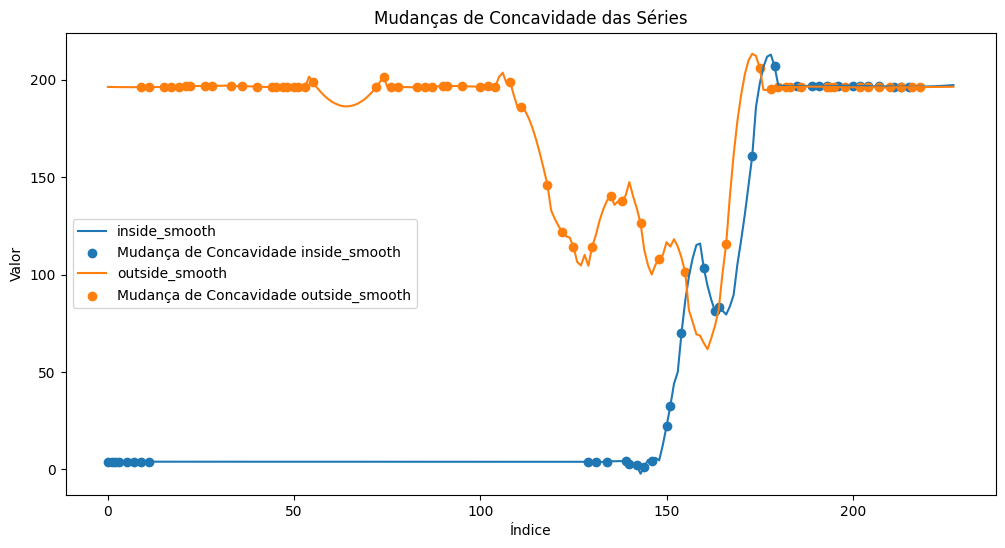

Picos encontrados nos índices: inside_smooth
Vales encontrados nos índices: outside_smooth


In [498]:
name_col = ["inside_smooth", "outside_smooth"]
peaks, valleys = analyze_concavity_changes(data, name_col)
print("Picos encontrados nos índices:", peaks)
print("Vales encontrados nos índices:", valleys)

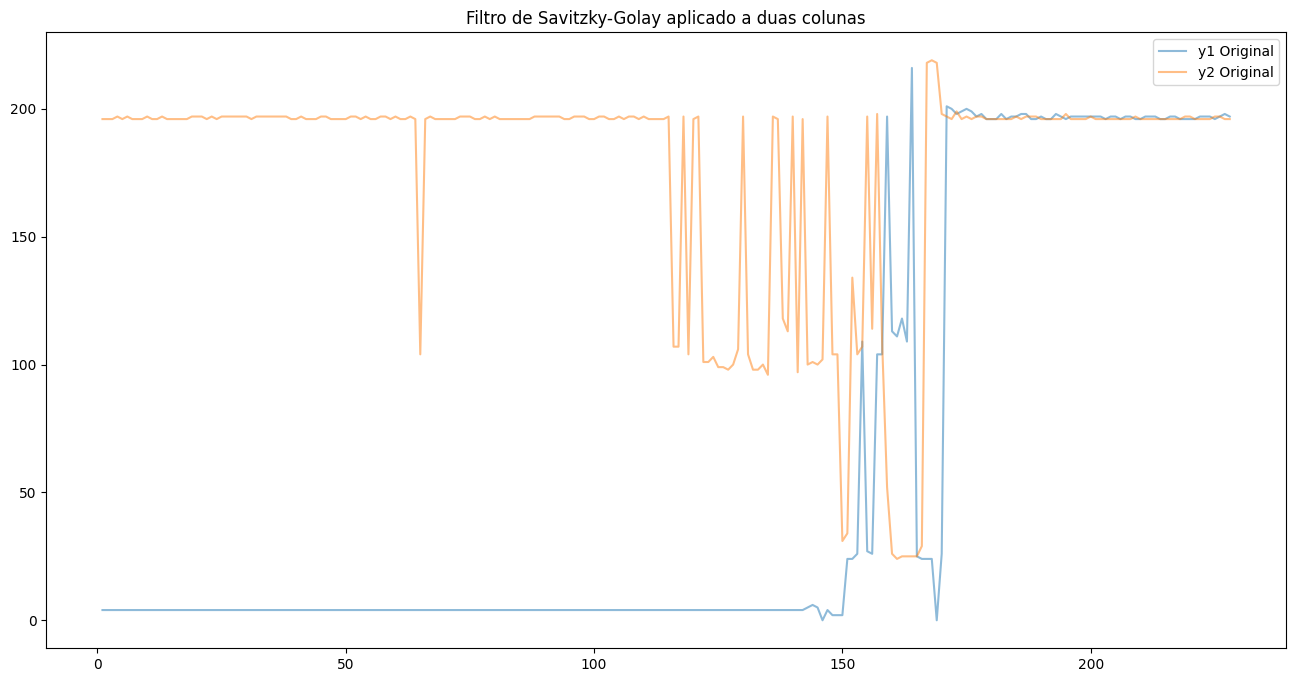

In [499]:
plt.figure(figsize=(16, 8))
plt.plot(df['id'], df['distance_cm_inside'], label='y1 Original', alpha=0.5)
#plt.plot(df['id'], df['inside_smooth'], label='y1 Suavizado', linewidth=2)
plt.plot(df['id'], df['distance_cm_outside'], label='y2 Original', alpha=0.5)
#plt.plot(df['id'], df['outside_smooth'], label='y2 Suavizado', linewidth=2)
plt.legend()
plt.title('Filtro de Savitzky-Golay aplicado a duas colunas')
plt.show()

Começando o WMA

In [500]:
def weightedmovingaverage(series, period):
    """
    Calcula a Média Móvel Ponderada (WMA) para uma série do pandas.

    :param series: pd.Series contendo os dados numéricos
    :param period: int, número de períodos para o cálculo da média ponderada
    :return: pd.Series com os valores da média ponderada
    """
    weighted = []
    data_array = series.values  # Converte para um array NumPy
    
    for i in range(len(data_array)):
        if i < period - 1:
            weighted.append(None)  # Preenche os primeiros valores com None para manter o alinhamento
        else:
            total = np.arange(1, period + 1, 1)  # Vetor de pesos
            matrix = data_array[i - period + 1: i + 1]  # Janela de dados
            matrix = total * matrix  # Multiplicação pelos pesos
            
            wma = matrix.sum() / total.sum()  # Cálculo da média ponderada
            weighted.append(wma)  # Adiciona ao resultado
    
    return pd.Series(weighted, index=series.index)  # Retorna como uma Série do pandas

In [501]:
df = backup_data

window_size = 25

df['inside_smooth'] = weightedmovingaverage(df['distance_cm_inside'], window_size)
df['outside_smooth'] = weightedmovingaverage(df['distance_cm_outside'], window_size)

plt.figure(figsize=(16, 8))
#plt.plot(df['id'], df['distance_cm_inside'], label='y1 Original', alpha=0.5)
plt.plot(df['id'], df['inside_smooth'], label='inside', linewidth=2)
#plt.plot(df['id'], df['distance_cm_outside'], label='y2 Original', alpha=0.5)
plt.plot(df['id'], df['outside_smooth'], label='outside', linewidth=2)
plt.legend()
plt.title(f"WMA_{name}")
filename = f"WMA_{name}.png"

# Salvando o gráfico como PNG
#plt.gca().invert_yaxis()
plt.savefig(filename, dpi=300, bbox_inches='tight')
#plt.show()
plt.close()




Começando o AWMA

## Binarização média simples

### Binarizando

In [248]:
bin_data = simple_mean
bin_data

,distance_cm_inside,distance_cm_outside,id
0,4.000000,196.333333,1
1,4.000000,196.714286,2
2,4.000000,196.428571,3
3,4.000000,191.904762,4
4,4.000000,196.571429,5
5,4.000000,160.714286,6
6,4.000000,129.095238,7
7,67.190476,90.666667,8
8,180.095238,197.666667,9
9,196.714286,196.190476,10


In [249]:
#O que é zero é erro;
#Realmente é?
#Não é erro! Deveria, mas não é!
#bin_data = bin_data[(bin_data['distance_cm_inside'] != 0) & (bin_data['distance_cm_outside'] != 0)]
#bin_data

In [250]:
#Binarizando
bin_data['state_inside_sensor'] = bin_data['distance_cm_inside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data['state_outside_sensor'] = bin_data['distance_cm_outside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data

,distance_cm_inside,distance_cm_outside,id,state_inside_sensor,state_outside_sensor
0,4.000000,196.333333,1,1,0
1,4.000000,196.714286,2,1,0
2,4.000000,196.428571,3,1,0
3,4.000000,191.904762,4,1,0
4,4.000000,196.571429,5,1,0
5,4.000000,160.714286,6,1,0
6,4.000000,129.095238,7,1,0
7,67.190476,90.666667,8,1,1
8,180.095238,197.666667,9,0,0
9,196.714286,196.190476,10,0,0


In [251]:
def determine_state(row):
    #sem excitação
    if row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 0:
        return 0
    #tem algo na saída
    elif row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 1:
        return 1
    #tem algo na entrada
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 0:
        return 2
    #os dois estão ativados
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 1:
        return 3

bin_data['state'] = bin_data.apply(determine_state, axis=1)
bin_data

,distance_cm_inside,distance_cm_outside,id,state_inside_sensor,state_outside_sensor,state
0,4.000000,196.333333,1,1,0,2
1,4.000000,196.714286,2,1,0,2
2,4.000000,196.428571,3,1,0,2
3,4.000000,191.904762,4,1,0,2
4,4.000000,196.571429,5,1,0,2
5,4.000000,160.714286,6,1,0,2
6,4.000000,129.095238,7,1,0,2
7,67.190476,90.666667,8,1,1,3
8,180.095238,197.666667,9,0,0,0
9,196.714286,196.190476,10,0,0,0


In [252]:
print(bin_data['state'].value_counts().sort_index())

state
0    3
2    7
3    1
Name: count, dtype: int64


### Plote das medidas com colorização por estados

In [253]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data['state']]
colors_outside = [color_map[state] for state in bin_data['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data['id'], bin_data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data['id'], bin_data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data['id'], bin_data['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data['id'], bin_data['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title(f"Gráfico de Distâncias Interna e Externa (com média simples {n})", fontsize=16)


# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
#plt.show()
filename = f"grafico_media_simples_{n}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()

### Tratamento para sub-dataframes

In [254]:
#Função parece ruim!
#Seria bom analisar mais afundo e conseguir enchergar os state 3.
#Armazeno os índices de todos os eventos que possues state = 3
state_3_indices = bin_data[bin_data['state'] == 3].index

def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Dicionário para armazenar os sub-DataFrames
sub_dataframes = {}

# Criar sub-DataFrames para cada índice onde state = 3
for i in range(1, len(state_3_indices)):
    #armazena o índice atual que possue state = 3
    current_idx = state_3_indices[i]
    #armazena current_idx - 1
    previous_idx = state_3_indices[i - 1]
    #não pegar os mesmos ranges
    if current_idx > previous_idx + 25:
        print(current_idx)
        # Aqui você pode adicionar o que deseja fazer quando a condição for verdadeira
        sub_dataframes[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data, current_idx, window=25)


In [255]:
# Função para criar sub-DataFrames com base em um índice e uma janela
def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Armazenar os índices de todos os eventos onde state != 0
non_zero_state_indices = bin_data[bin_data['state'] != 0].index

# Dicionário para armazenar os sub-DataFrames
sub_dataframes_1 = {}

# Criar sub-DataFrames para cada índice onde state != 0
for i, current_idx in enumerate(non_zero_state_indices):
    # Verificar se o índice atual não está muito próximo do anterior
    if i == 0 or current_idx > non_zero_state_indices[i - 1] + 25:
        print(f"Criando sub-DataFrame para o índice {current_idx}")
        sub_dataframes_1[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data, current_idx, window=25)

# Exibir os sub-DataFrames criados
for key, sub_df in sub_dataframes_1.items():
    print(f"\n{key}:\n{sub_df}")

Criando sub-DataFrame para o índice 0

sub_df_0:
    distance_cm_inside  distance_cm_outside  id  state_inside_sensor  \
0             4.000000           196.333333   1                    1   
1             4.000000           196.714286   2                    1   
2             4.000000           196.428571   3                    1   
3             4.000000           191.904762   4                    1   
4             4.000000           196.571429   5                    1   
5             4.000000           160.714286   6                    1   
6             4.000000           129.095238   7                    1   
7            67.190476            90.666667   8                    1   
8           180.095238           197.666667   9                    0   
9           196.714286           196.190476  10                    0   
10          196.666667           196.222222  11                    0   

    state_outside_sensor  state  
0                      0      2  
1                 

In [256]:
print(state_3_indices)

Index([7], dtype='int64')


In [257]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}
state_map = {0: 'Inativo', 1: 'Ativ. externa', 2: 'Ativ. interna', 3: 'Ativ. dupla'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'{state_map[state]}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
#plt.show()
filename = f"grafico_media_simples_{n}_sub_dataframes.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()


1


In [258]:
#Estado da linha anterior
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
#Percorrendo dicionário de eventos:
count = 0
for key, df in sub_dataframes_1.items():
  print(key)
  previous_state = 0
  state_machine = 0
  # Convertendo a coluna 'measured_at' para datetime
  #df['measured_at'] = pd.to_datetime(df['measured_at'])
  #Percorrendo cada linha de cada evento
  for index, row in df.iterrows():
    #print(row['state'], state_machine)
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count =+ 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count =- 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
  print("")
print("Quantidade de pessoas:", end=" ")
print(count)



sub_df_0
Evento de interesse:
Alguém está saindo... A pessoa desistiu de sair

Quantidade de pessoas: 0


1


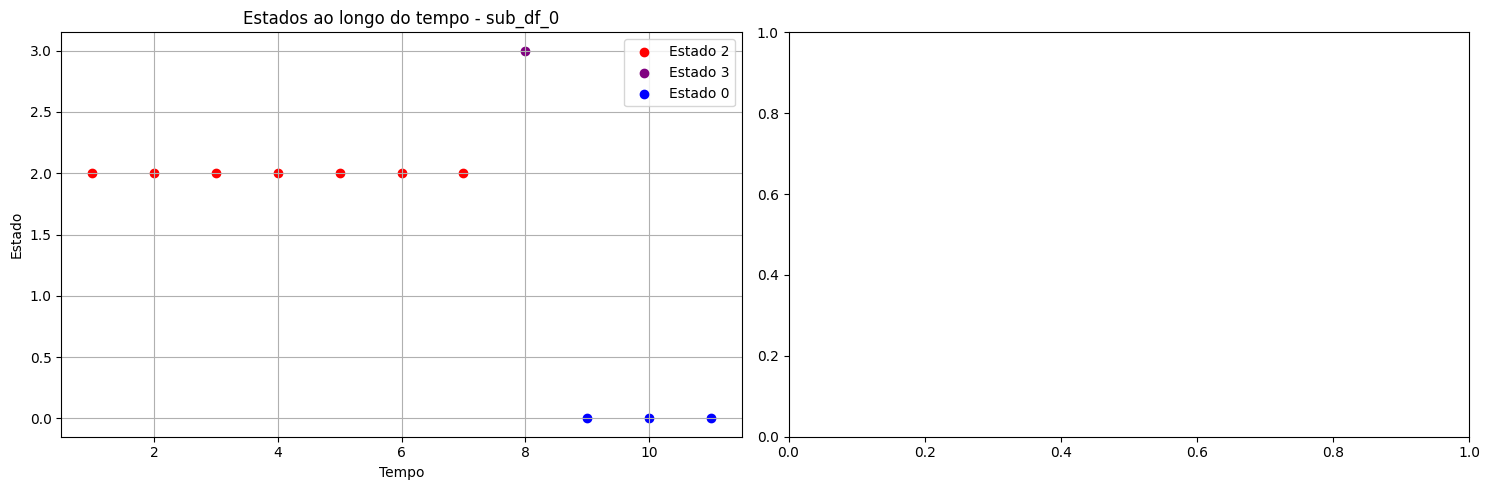

In [259]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'Estado {state}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

In [260]:
#Estado da linha anterior
previous_state = 0
count = 0
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
state_machine = 0
for index, row in bin_data.iterrows():
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:", end=" ")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count = count + 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count = count - 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
print(count)  

Evento de interesse: Alguém está saindo... A pessoa desistiu de sair
0


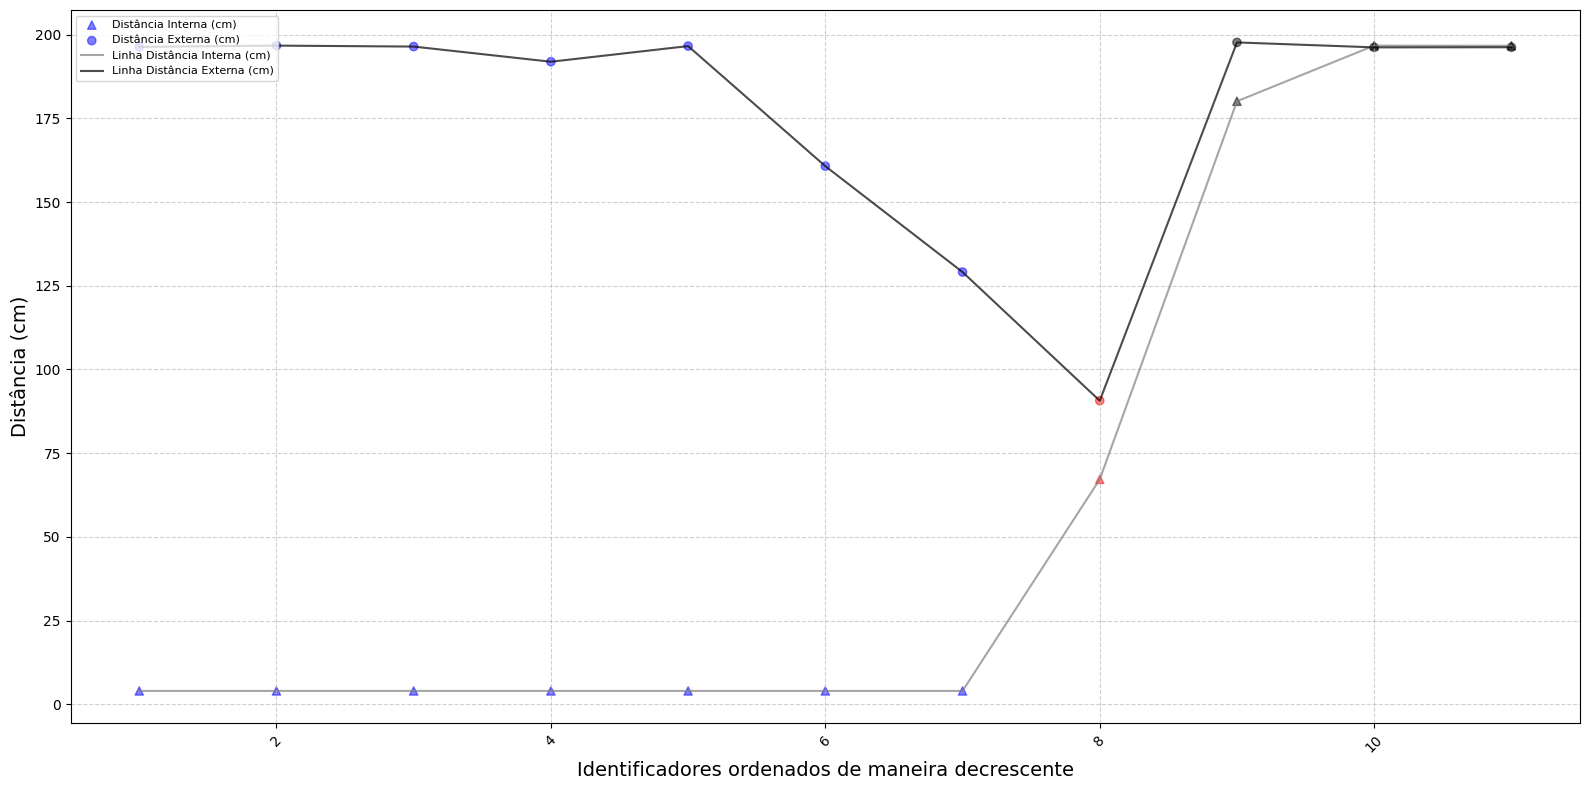

In [261]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'bin_data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data['state']]
colors_outside = [color_map[state] for state in bin_data['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data['id'], bin_data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data['id'], bin_data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data['id'], bin_data['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data['id'], bin_data['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [262]:
bin_data

,distance_cm_inside,distance_cm_outside,id,state_inside_sensor,state_outside_sensor,state
0,4.000000,196.333333,1,1,0,2
1,4.000000,196.714286,2,1,0,2
2,4.000000,196.428571,3,1,0,2
3,4.000000,191.904762,4,1,0,2
4,4.000000,196.571429,5,1,0,2
5,4.000000,160.714286,6,1,0,2
6,4.000000,129.095238,7,1,0,2
7,67.190476,90.666667,8,1,1,3
8,180.095238,197.666667,9,0,0,0
9,196.714286,196.190476,10,0,0,0


## Binarização média quadrática

### Binarizando

In [332]:
bin_data = quadratic_means_df
#bin_data

In [333]:
#O que é zero é erro;
#Realmente é?
#Não é erro! Deveria, mas não é!
#bin_data = bin_data[(bin_data['distance_cm_inside'] != 0) & (bin_data['distance_cm_outside'] != 0)]
#bin_data

In [334]:
#Binarizando
bin_data['state_inside_sensor'] = bin_data['distance_cm_inside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data['state_outside_sensor'] = bin_data['distance_cm_outside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data

,id,distance_cm_inside,distance_cm_outside,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor
0,1,197.429674,196.623522,1.964763e+06,0.000000,32.000000,44.335840,516.804098,0,0
1,2,197.477304,196.289873,1.965910e+06,0.000000,32.000000,45.478933,511.132170,0,0
2,3,197.429192,196.050649,1.967092e+06,0.000000,32.000000,46.669048,526.351277,0,0
3,4,197.524923,195.859644,1.968242e+06,0.000000,32.000000,47.811136,525.541172,0,0
4,5,197.286956,196.669653,1.969558e+06,0.000000,32.000000,49.097086,561.113307,0,0
5,6,197.429433,196.432346,1.970746e+06,0.000000,32.000000,50.287743,547.974104,0,0
6,7,196.905706,196.621100,1.971925e+06,0.000000,32.000000,51.478613,536.822175,0,0
7,8,197.049667,196.622069,1.973083e+06,0.000000,32.000000,52.621288,557.840479,0,0
8,9,160.452337,196.764786,1.974296e+06,0.000000,32.000000,53.810957,567.759674,0,0
9,10,126.313292,189.998496,1.975402e+06,0.000000,32.000000,54.905547,587.164534,0,0


In [335]:
def determine_state(row):
    #sem excitação
    if row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 0:
        return 0
    #tem algo na saída
    elif row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 1:
        return 1
    #tem algo na entrada
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 0:
        return 2
    #os dois estão ativados
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 1:
        return 3

bin_data['state'] = bin_data.apply(determine_state, axis=1)
bin_data

,id,distance_cm_inside,distance_cm_outside,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor,state
0,1,197.429674,196.623522,1.964763e+06,0.000000,32.000000,44.335840,516.804098,0,0,0
1,2,197.477304,196.289873,1.965910e+06,0.000000,32.000000,45.478933,511.132170,0,0,0
2,3,197.429192,196.050649,1.967092e+06,0.000000,32.000000,46.669048,526.351277,0,0,0
3,4,197.524923,195.859644,1.968242e+06,0.000000,32.000000,47.811136,525.541172,0,0,0
4,5,197.286956,196.669653,1.969558e+06,0.000000,32.000000,49.097086,561.113307,0,0,0
5,6,197.429433,196.432346,1.970746e+06,0.000000,32.000000,50.287743,547.974104,0,0,0
6,7,196.905706,196.621100,1.971925e+06,0.000000,32.000000,51.478613,536.822175,0,0,0
7,8,197.049667,196.622069,1.973083e+06,0.000000,32.000000,52.621288,557.840479,0,0,0
8,9,160.452337,196.764786,1.974296e+06,0.000000,32.000000,53.810957,567.759674,0,0,0
9,10,126.313292,189.998496,1.975402e+06,0.000000,32.000000,54.905547,587.164534,0,0,0


In [336]:
print(bin_data['state'].value_counts().sort_index())

state
0    34
Name: count, dtype: int64


### Plote das medidas com colorização por estados

In [337]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data['state']]
colors_outside = [color_map[state] for state in bin_data['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data['id'], bin_data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data['id'], bin_data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data['id'], bin_data['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data['id'], bin_data['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title(f'Gráfico de Distâncias Interna e Externa (com média quadrática {n})', fontsize=16)


# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
#plt.show()
filename = f"grafico_media_quadratica_{n}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()

### Tratamento para sub-dataframes

In [338]:
#Função parece ruim!
#Seria bom analisar mais afundo e conseguir enchergar os state 3.
#Armazeno os índices de todos os eventos que possues state = 3
state_3_indices = bin_data[bin_data['state'] == 3].index

def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Dicionário para armazenar os sub-DataFrames
sub_dataframes = {}

# Criar sub-DataFrames para cada índice onde state = 3
for i in range(1, len(state_3_indices)):
    #armazena o índice atual que possue state = 3
    current_idx = state_3_indices[i]
    #armazena current_idx - 1
    previous_idx = state_3_indices[i - 1]
    #não pegar os mesmos ranges
    if current_idx > previous_idx + 25:
        print(current_idx)
        # Aqui você pode adicionar o que deseja fazer quando a condição for verdadeira
        sub_dataframes[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data, current_idx, window=25)


In [339]:
# Função para criar sub-DataFrames com base em um índice e uma janela
def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Armazenar os índices de todos os eventos onde state != 0
non_zero_state_indices = bin_data[bin_data['state'] != 0].index

# Dicionário para armazenar os sub-DataFrames
sub_dataframes_1 = {}

# Criar sub-DataFrames para cada índice onde state != 0
for i, current_idx in enumerate(non_zero_state_indices):
    # Verificar se o índice atual não está muito próximo do anterior
    if i == 0 or current_idx > non_zero_state_indices[i - 1] + 25:
        print(f"Criando sub-DataFrame para o índice {current_idx}")
        sub_dataframes_1[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data, current_idx, window=25)

# Exibir os sub-DataFrames criados
for key, sub_df in sub_dataframes_1.items():
    print(f"\n{key}:\n{sub_df}")

In [340]:
print(state_3_indices)

Index([], dtype='int64')


In [341]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}
state_map = {0: 'Inativo', 1: 'Ativ. externa', 2: 'Ativ. interna', 3: 'Ativ. dupla'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'{state_map[state]}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
#plt.show()
filename = f"grafico_media_quadratica_{n}_sub_dataframes.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()


0


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1500x0 with 0 Axes>

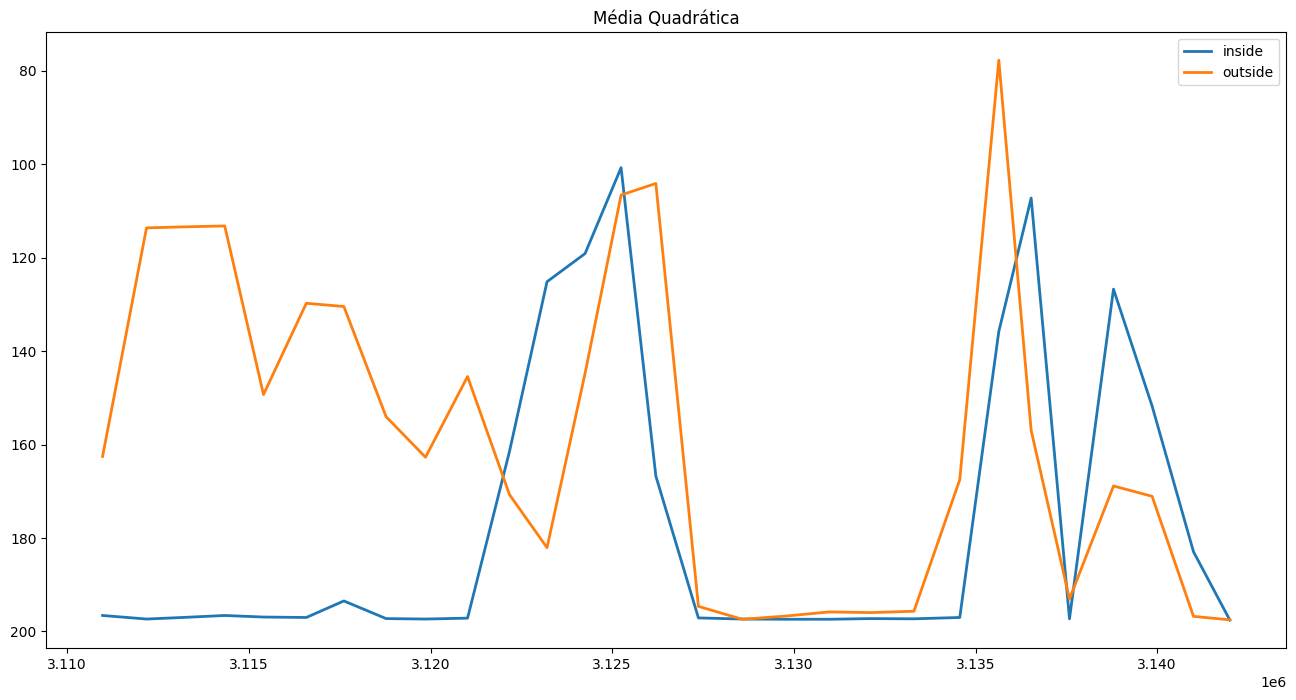

In [ ]:
plt.figure(figsize=(16, 8))
#plt.plot(bin_data['id'], bin_data['distance_cm_inside'], label='y1 Original', alpha=0.5)
plt.plot(bin_data['measured_at'], bin_data['distance_cm_inside'], label='inside', linewidth=2)
#plt.plot(bin_data['id'], bin_data['distance_cm_outside'], label='y2 Original', alpha=0.5)
plt.plot(bin_data['measured_at'], bin_data['distance_cm_outside'], label='outside', linewidth=2)
plt.legend()
plt.title('Média Quadrática')
filename = f"Média_quadratica_{name}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.gca().invert_yaxis()
plt.show()
plt.close()

In [262]:
#Estado da linha anterior
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
#Percorrendo dicionário de eventos:
count = 0
for key, df in sub_dataframes_1.items():
  print(key)
  previous_state = 0
  state_machine = 0
  # Convertendo a coluna 'measured_at' para datetime
  #df['measured_at'] = pd.to_datetime(df['measured_at'])
  #Percorrendo cada linha de cada evento
  for index, row in df.iterrows():
    #print(row['state'], state_machine)
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count =+ 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count =- 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
  print("")
print("Quantidade de pessoas:", end=" ")
print(count)



sub_df_22

Quantidade de pessoas: 0


1


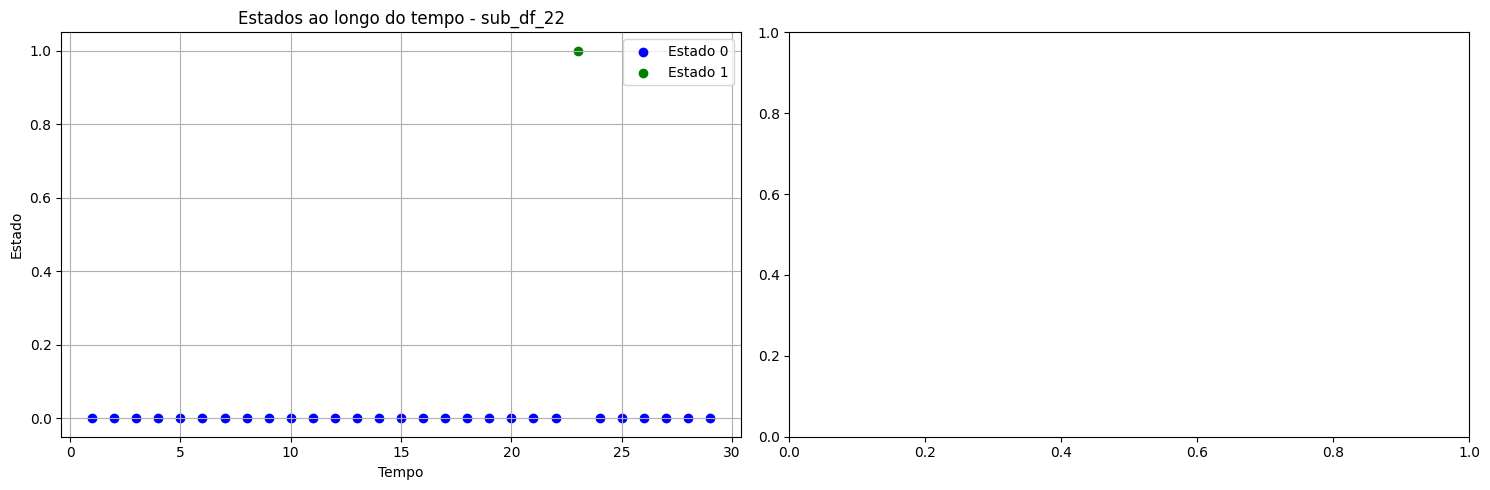

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'Estado {state}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

In [264]:
#Estado da linha anterior
previous_state = 0
count = 0
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
state_machine = 0
for index, row in bin_data.iterrows():
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:", end=" ")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count = count + 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count = count - 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
print(count)  

0


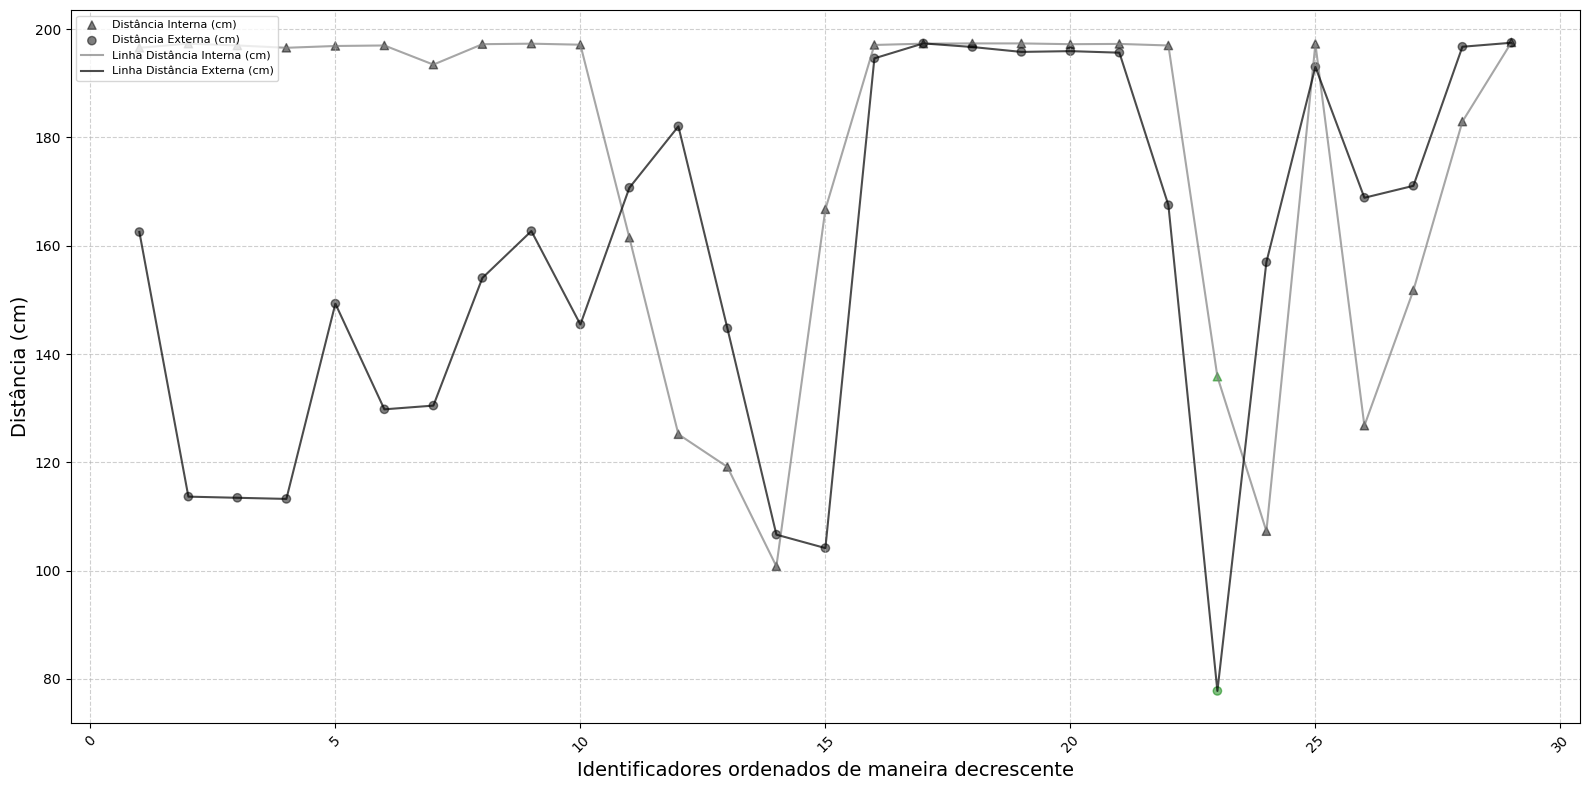

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'bin_data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data['state']]
colors_outside = [color_map[state] for state in bin_data['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data['id'], bin_data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data['id'], bin_data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data['id'], bin_data['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data['id'], bin_data['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [266]:
bin_data

,id,distance_cm_inside,distance_cm_outside,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor,state
0,1,196.573263,162.539373,3.110974e+06,0.000000,51.000000,50.573850,505.630441,0,0,0
1,2,197.334862,113.650676,3.112182e+06,0.000000,51.000000,51.716259,553.093121,0,0,0
2,3,197.002175,113.439516,3.113169e+06,0.000000,51.000000,52.763624,498.102160,0,0,0
3,4,196.572778,113.232588,3.114335e+06,0.000000,51.000000,53.810957,609.942386,0,0,0
4,5,196.906190,149.307130,3.115403e+06,0.000000,51.000000,54.905547,610.751957,0,0,0
5,6,197.001209,129.781318,3.116581e+06,0.000000,51.000000,56.143948,531.239073,0,0,0
6,7,193.463667,130.469664,3.117614e+06,0.000000,51.000000,57.239680,466.005518,0,0,0
7,8,197.239038,154.052867,3.118777e+06,0.000000,51.000000,58.335238,530.703980,0,0,0
8,9,197.333896,162.712425,3.119862e+06,0.000000,51.430952,44.599808,530.354149,0,0,0
9,10,197.143168,145.452005,3.121019e+06,0.000000,52.000000,0.755929,540.232710,0,0,0


## Binarização média geométrica

### Binarizando

In [267]:
bin_data = geometric_means_df
#bin_data

In [268]:
#O que é zero é erro;
#Realmente é?
#Não é erro! Deveria, mas não é!
#bin_data = bin_data[(bin_data['distance_cm_inside'] != 0) & (bin_data['distance_cm_outside'] != 0)]
#bin_data

In [ ]:
#Binarizando
bin_data['state_inside_sensor'] = bin_data['distance_cm_inside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data['state_outside_sensor'] = bin_data['distance_cm_outside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data

,id,distance_cm_inside,distance_cm_outside,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor
0,1,196.569599,147.903910,3.110974e+06,0.0,51.000000,50.569003,196.749256,0,0
1,2,197.331802,107.582045,3.112182e+06,0.0,51.000000,51.712302,283.291600,0,0
2,3,196.997824,107.327972,3.113169e+06,0.0,51.000000,52.760174,257.603986,0,0
3,4,196.570082,107.224288,3.114335e+06,0.0,51.000000,53.808080,390.400305,0,0
4,5,196.903334,133.902390,3.115403e+06,0.0,51.000000,54.903969,270.422856,0,0
5,6,196.998791,117.904039,3.116581e+06,0.0,51.000000,56.141776,275.546332,0,0
6,7,190.784678,118.213306,3.117614e+06,0.0,51.000000,57.236520,249.122245,0,0
7,8,197.237152,138.852012,3.118777e+06,0.0,51.000000,58.331436,262.498804,0,0
8,9,197.332771,147.906541,3.119862e+06,0.0,51.426195,0.000000,297.287197,0,0
9,10,197.142547,130.177494,3.121019e+06,0.0,52.000000,0.000000,247.611401,0,0


In [ ]:
def determine_state(row):
    #sem excitação
    if row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 0:
        return 0
    #tem algo na saída
    elif row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 1:
        return 1
    #tem algo na entrada
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 0:
        return 2
    #os dois estão ativados
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 1:
        return 3

bin_data['state'] = bin_data.apply(determine_state, axis=1)
bin_data

,id,distance_cm_inside,distance_cm_outside,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor,state
0,1,196.569599,147.903910,3.110974e+06,0.0,51.000000,50.569003,196.749256,0,0,0
1,2,197.331802,107.582045,3.112182e+06,0.0,51.000000,51.712302,283.291600,0,0,0
2,3,196.997824,107.327972,3.113169e+06,0.0,51.000000,52.760174,257.603986,0,0,0
3,4,196.570082,107.224288,3.114335e+06,0.0,51.000000,53.808080,390.400305,0,0,0
4,5,196.903334,133.902390,3.115403e+06,0.0,51.000000,54.903969,270.422856,0,0,0
5,6,196.998791,117.904039,3.116581e+06,0.0,51.000000,56.141776,275.546332,0,0,0
6,7,190.784678,118.213306,3.117614e+06,0.0,51.000000,57.236520,249.122245,0,0,0
7,8,197.237152,138.852012,3.118777e+06,0.0,51.000000,58.331436,262.498804,0,0,0
8,9,197.332771,147.906541,3.119862e+06,0.0,51.426195,0.000000,297.287197,0,0,0
9,10,197.142547,130.177494,3.121019e+06,0.0,52.000000,0.000000,247.611401,0,0,0


In [271]:
print(bin_data['state'].value_counts().sort_index())

state
0    22
1     1
2     4
3     2
Name: count, dtype: int64


### Plote das medidas com colorização por estados

In [272]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data['state']]
colors_outside = [color_map[state] for state in bin_data['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data['id'], bin_data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data['id'], bin_data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data['id'], bin_data['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data['id'], bin_data['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title(f'Gráfico de Distâncias Interna e Externa (com média geométrica {n})', fontsize=16)


# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()
# Exibir o gráfico
#plt.show()
filename = f"grafico_media_geométrica_{n}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()

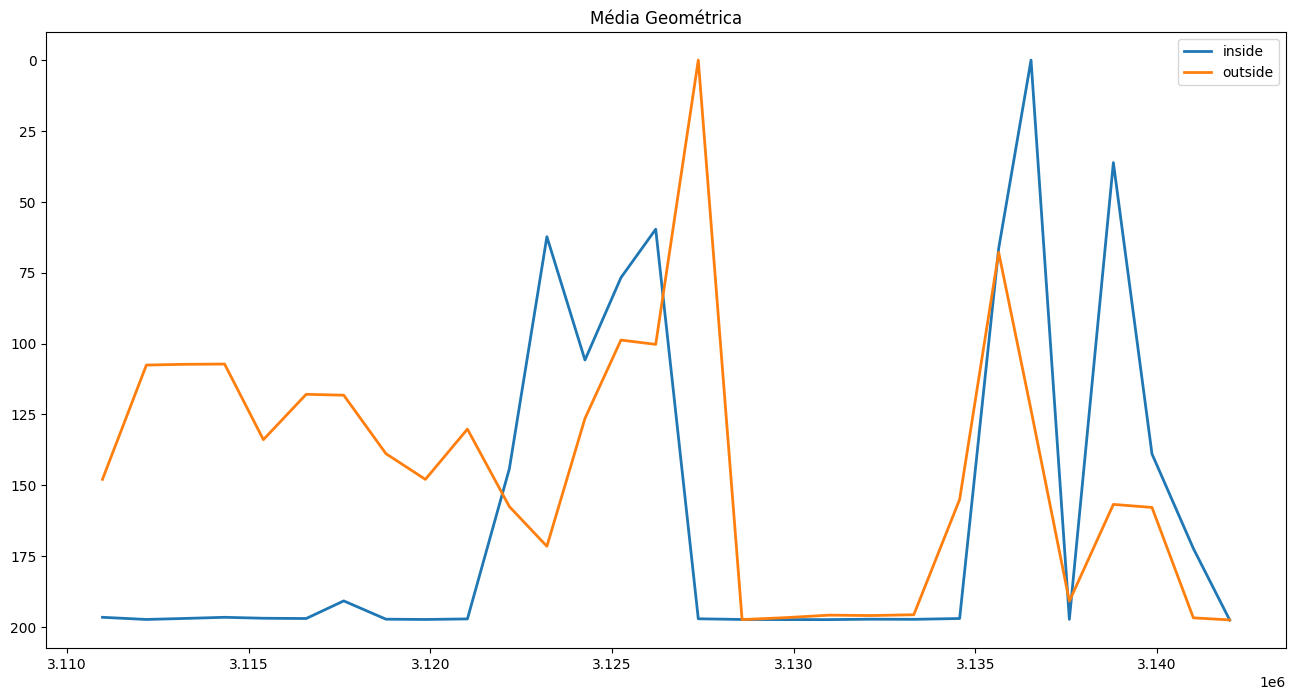

In [ ]:
plt.figure(figsize=(16, 8))
#plt.plot(bin_data['id'], bin_data['distance_cm_inside'], label='y1 Original', alpha=0.5)
plt.plot(bin_data['measured_at'], bin_data['distance_cm_inside'], label='inside', linewidth=2)
#plt.plot(bin_data['id'], bin_data['distance_cm_outside'], label='y2 Original', alpha=0.5)
plt.plot(bin_data['measured_at'], bin_data['distance_cm_outside'], label='outside', linewidth=2)
plt.legend()
plt.title('Média Geométrica')
filename = f"Média_geométrica_{name}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.gca().invert_yaxis()
plt.show()
plt.close()

### Tratamento para sub-dataframes

In [274]:
#Função parece ruim!
#Seria bom analisar mais afundo e conseguir enchergar os state 3.
#Armazeno os índices de todos os eventos que possues state = 3
state_3_indices = bin_data[bin_data['state'] == 3].index

def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Dicionário para armazenar os sub-DataFrames
sub_dataframes = {}

# Criar sub-DataFrames para cada índice onde state = 3
for i in range(1, len(state_3_indices)):
    #armazena o índice atual que possue state = 3
    current_idx = state_3_indices[i]
    #armazena current_idx - 1
    previous_idx = state_3_indices[i - 1]
    #não pegar os mesmos ranges
    if current_idx > previous_idx + 25:
        print(current_idx)
        # Aqui você pode adicionar o que deseja fazer quando a condição for verdadeira
        sub_dataframes[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data, current_idx, window=25)


In [275]:
# Função para criar sub-DataFrames com base em um índice e uma janela
def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Armazenar os índices de todos os eventos onde state != 0
non_zero_state_indices = bin_data[bin_data['state'] != 0].index

# Dicionário para armazenar os sub-DataFrames
sub_dataframes_1 = {}

# Criar sub-DataFrames para cada índice onde state != 0
for i, current_idx in enumerate(non_zero_state_indices):
    # Verificar se o índice atual não está muito próximo do anterior
    if i == 0 or current_idx > non_zero_state_indices[i - 1] + 25:
        print(f"Criando sub-DataFrame para o índice {current_idx}")
        sub_dataframes_1[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data, current_idx, window=25)

# Exibir os sub-DataFrames criados
for key, sub_df in sub_dataframes_1.items():
    print(f"\n{key}:\n{sub_df}")

Criando sub-DataFrame para o índice 11

sub_df_11:
    id  distance_cm_inside  distance_cm_outside   measured_at  errors  \
0    1          196.569599           147.903910  3.110974e+06     0.0   
1    2          197.331802           107.582045  3.112182e+06     0.0   
2    3          196.997824           107.327972  3.113169e+06     0.0   
3    4          196.570082           107.224288  3.114335e+06     0.0   
4    5          196.903334           133.902390  3.115403e+06     0.0   
5    6          196.998791           117.904039  3.116581e+06     0.0   
6    7          190.784678           118.213306  3.117614e+06     0.0   
7    8          197.237152           138.852012  3.118777e+06     0.0   
8    9          197.332771           147.906541  3.119862e+06     0.0   
9   10          197.142547           130.177494  3.121019e+06     0.0   
10  11          144.181936           157.508215  3.122173e+06     0.0   
11  12           62.304553           171.516527  3.123206e+06     0.0   


In [276]:
print(state_3_indices)

Index([13, 22], dtype='int64')


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}
state_map = {0: 'Inativo', 1: 'Ativ. externa', 2: 'Ativ. interna', 3: 'Ativ. dupla'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'{state_map[state]}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
#plt.show()
filename = f"grafico_media_geometrica_{n}_sub_dataframes.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()



1


In [278]:
#Estado da linha anterior
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
#Percorrendo dicionário de eventos:
count = 0
for key, df in sub_dataframes_1.items():
  print(key)
  previous_state = 0
  state_machine = 0
  # Convertendo a coluna 'measured_at' para datetime
  #df['measured_at'] = pd.to_datetime(df['measured_at'])
  #Percorrendo cada linha de cada evento
  for index, row in df.iterrows():
    #print(row['state'], state_machine)
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count =+ 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count =- 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
  print("")
print("Quantidade de pessoas:", end=" ")
print(count)



sub_df_11
Evento de interesse:
Evento de interesse:

Quantidade de pessoas: 0


1


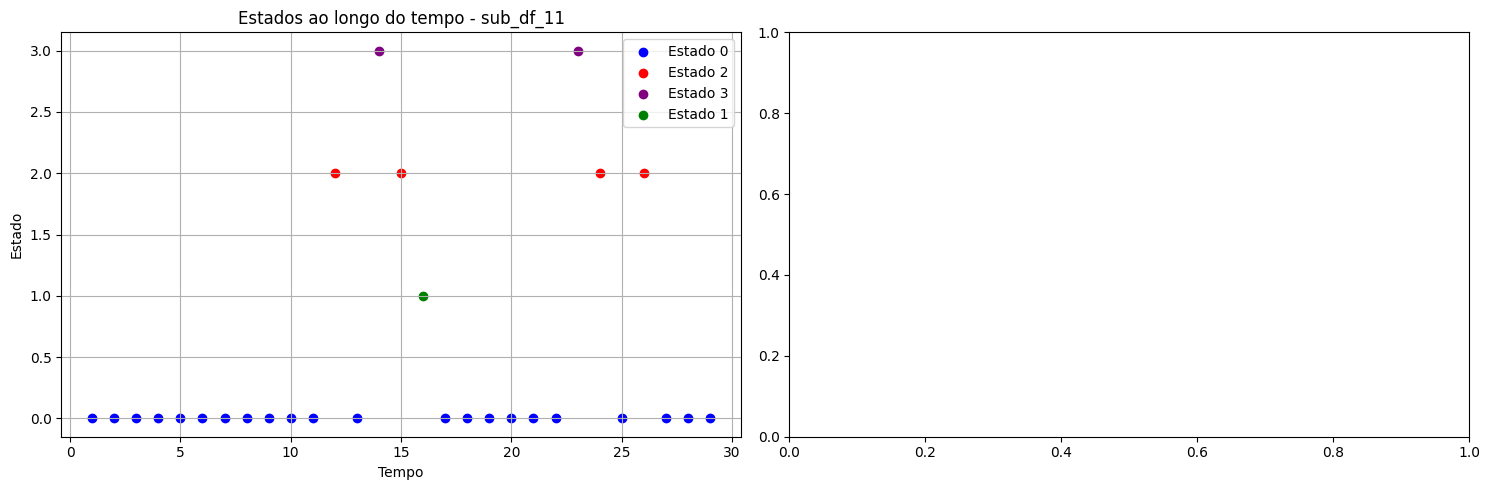

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'Estado {state}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

In [280]:
#Estado da linha anterior
previous_state = 0
count = 0
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
state_machine = 0
for index, row in bin_data.iterrows():
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:", end=" ")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count = count + 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count = count - 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
print(count)  

Evento de interesse: Evento de interesse: 0


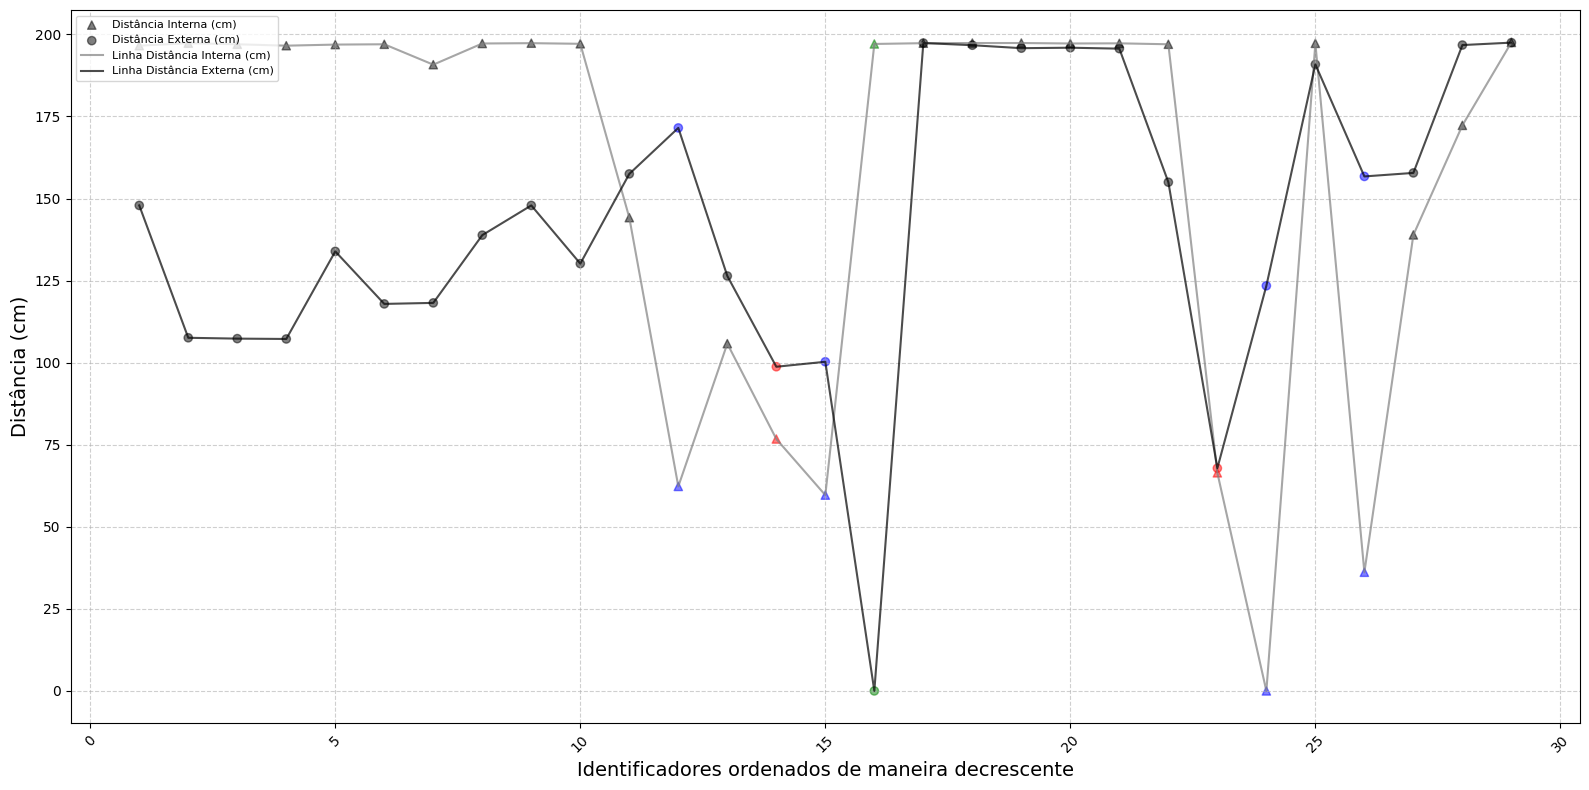

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'bin_data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data['state']]
colors_outside = [color_map[state] for state in bin_data['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data['id'], bin_data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data['id'], bin_data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data['id'], bin_data['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data['id'], bin_data['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [282]:
bin_data

,id,distance_cm_inside,distance_cm_outside,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor,state
0,1,196.569599,147.903910,3.110974e+06,0.0,51.000000,50.569003,196.749256,0,0,0
1,2,197.331802,107.582045,3.112182e+06,0.0,51.000000,51.712302,283.291600,0,0,0
2,3,196.997824,107.327972,3.113169e+06,0.0,51.000000,52.760174,257.603986,0,0,0
3,4,196.570082,107.224288,3.114335e+06,0.0,51.000000,53.808080,390.400305,0,0,0
4,5,196.903334,133.902390,3.115403e+06,0.0,51.000000,54.903969,270.422856,0,0,0
5,6,196.998791,117.904039,3.116581e+06,0.0,51.000000,56.141776,275.546332,0,0,0
6,7,190.784678,118.213306,3.117614e+06,0.0,51.000000,57.236520,249.122245,0,0,0
7,8,197.237152,138.852012,3.118777e+06,0.0,51.000000,58.331436,262.498804,0,0,0
8,9,197.332771,147.906541,3.119862e+06,0.0,51.426195,0.000000,297.287197,0,0,0
9,10,197.142547,130.177494,3.121019e+06,0.0,52.000000,0.000000,247.611401,0,0,0


## Binarização média móvel

### Binarizando

In [ ]:
bin_data = mean_data
#bin_data

NameError: name 'mean_data' is not defined

In [ ]:
#O que é zero é erro;
#Realmente é?
#Não é erro! Deveria, mas não é!
#bin_data = bin_data[(bin_data['distance_cm_inside'] != 0) & (bin_data['distance_cm_outside'] != 0)]
#bin_data

In [ ]:
#Binarizando
bin_data['state_inside_sensor'] = bin_data['distance_cm_inside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data['state_outside_sensor'] = bin_data['distance_cm_outside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor
0,1,196.56,196.52,F0:08:D1:D0:7B:84,1601124,0,26,41,124,0,0
1,2,196.60,196.56,F0:08:D1:D0:7B:84,1601181,0,26,41,181,0,0
2,3,196.56,196.60,F0:08:D1:D0:7B:84,1601238,0,26,41,238,0,0
3,4,196.56,196.64,F0:08:D1:D0:7B:84,1601297,0,26,41,297,0,0
4,5,196.52,196.64,F0:08:D1:D0:7B:84,1601354,0,26,41,354,0,0
...,...,...,...,...,...,...,...,...,...,...,...
549,550,143.04,192.36,F0:08:D1:D0:7B:84,1632003,0,27,12,3,0,0
550,551,150.80,196.16,F0:08:D1:D0:7B:84,1632357,0,27,12,357,0,0
551,552,158.60,196.04,F0:08:D1:D0:7B:84,1632414,0,27,12,414,0,0
552,553,166.36,195.92,F0:08:D1:D0:7B:84,1632471,0,27,12,471,0,0


In [ ]:
def determine_state(row):
    #sem excitação
    if row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 0:
        return 0
    #tem algo na saída
    elif row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 1:
        return 1
    #tem algo na entrada
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 0:
        return 2
    #os dois estão ativados
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 1:
        return 3

bin_data['state'] = bin_data.apply(determine_state, axis=1)
bin_data

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor,state
0,1,196.56,196.52,F0:08:D1:D0:7B:84,1601124,0,26,41,124,0,0,0
1,2,196.60,196.56,F0:08:D1:D0:7B:84,1601181,0,26,41,181,0,0,0
2,3,196.56,196.60,F0:08:D1:D0:7B:84,1601238,0,26,41,238,0,0,0
3,4,196.56,196.64,F0:08:D1:D0:7B:84,1601297,0,26,41,297,0,0,0
4,5,196.52,196.64,F0:08:D1:D0:7B:84,1601354,0,26,41,354,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
549,550,143.04,192.36,F0:08:D1:D0:7B:84,1632003,0,27,12,3,0,0,0
550,551,150.80,196.16,F0:08:D1:D0:7B:84,1632357,0,27,12,357,0,0,0
551,552,158.60,196.04,F0:08:D1:D0:7B:84,1632414,0,27,12,414,0,0,0
552,553,166.36,195.92,F0:08:D1:D0:7B:84,1632471,0,27,12,471,0,0,0


In [ ]:
print(bin_data['state'].value_counts().sort_index())

state
0    544
2     10
Name: count, dtype: int64


### Plote das medidas com colorização por estados

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data['state']]
colors_outside = [color_map[state] for state in bin_data['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data['id'], bin_data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data['id'], bin_data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data['id'], bin_data['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data['id'], bin_data['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title(f'Gráfico de Distâncias Interna e Externa (com média móvel {n})', fontsize=16)


# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
#plt.show()
filename = f"grafico_media_móvel_{n}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()

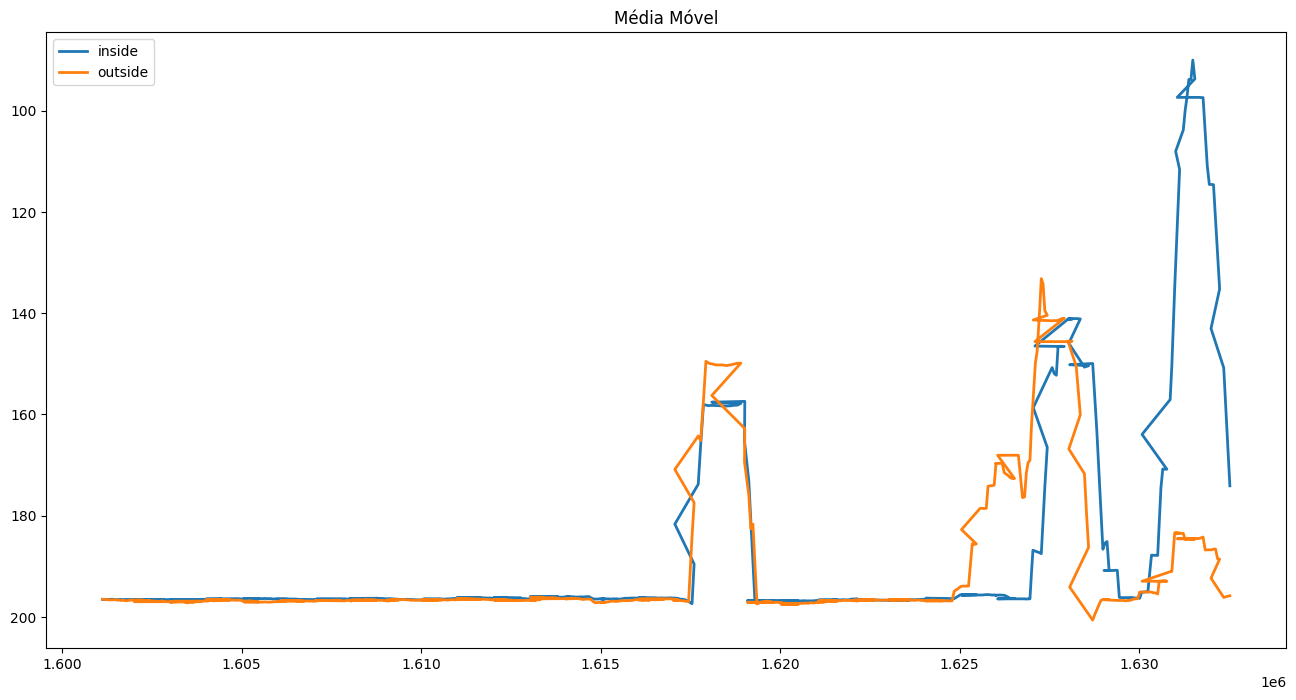

In [ ]:
plt.figure(figsize=(16, 8))
#plt.plot(bin_data['id'], bin_data['distance_cm_inside'], label='y1 Original', alpha=0.5)
plt.plot(bin_data['measured_at'], bin_data['distance_cm_inside'], label='inside', linewidth=2)
#plt.plot(bin_data['id'], bin_data['distance_cm_outside'], label='y2 Original', alpha=0.5)
plt.plot(bin_data['measured_at'], bin_data['distance_cm_outside'], label='outside', linewidth=2)
plt.legend()
plt.title('Média Móvel')
filename = f"Média_movel_{name}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.gca().invert_yaxis()
plt.show()
plt.close()

### Tratamento para sub-dataframes

In [ ]:
#Função parece ruim!
#Seria bom analisar mais afundo e conseguir enchergar os state 3.
#Armazeno os índices de todos os eventos que possues state = 3
state_3_indices = bin_data[bin_data['state'] == 3].index

def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Dicionário para armazenar os sub-DataFrames
sub_dataframes = {}

# Criar sub-DataFrames para cada índice onde state = 3
for i in range(1, len(state_3_indices)):
    #armazena o índice atual que possue state = 3
    current_idx = state_3_indices[i]
    #armazena current_idx - 1
    previous_idx = state_3_indices[i - 1]
    #não pegar os mesmos ranges
    if current_idx > previous_idx + 25:
        print(current_idx)
        # Aqui você pode adicionar o que deseja fazer quando a condição for verdadeira
        sub_dataframes[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data, current_idx, window=25)


In [ ]:
# Função para criar sub-DataFrames com base em um índice e uma janela
def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Armazenar os índices de todos os eventos onde state != 0
non_zero_state_indices = bin_data[bin_data['state'] != 0].index

# Dicionário para armazenar os sub-DataFrames
sub_dataframes_1 = {}

# Criar sub-DataFrames para cada índice onde state != 0
for i, current_idx in enumerate(non_zero_state_indices):
    # Verificar se o índice atual não está muito próximo do anterior
    if i == 0 or current_idx > non_zero_state_indices[i - 1] + 25:
        print(f"Criando sub-DataFrame para o índice {current_idx}")
        sub_dataframes_1[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data, current_idx, window=25)

# Exibir os sub-DataFrames criados
for key, sub_df in sub_dataframes_1.items():
    print(f"\n{key}:\n{sub_df}")

Criando sub-DataFrame para o índice 531

sub_df_531:
      id  distance_cm_inside  distance_cm_outside        device_code  \
506  507              196.32               195.08  F0:08:D1:D0:7B:84   
507  508              195.08               195.12  F0:08:D1:D0:7B:84   
508  509              195.12               195.08  F0:08:D1:D0:7B:84   
509  510              195.04               195.08  F0:08:D1:D0:7B:84   
510  511              195.08               195.08  F0:08:D1:D0:7B:84   
511  512              191.40               195.08  F0:08:D1:D0:7B:84   
512  513              187.80               195.12  F0:08:D1:D0:7B:84   
513  514              187.84               195.24  F0:08:D1:D0:7B:84   
514  515              187.84               195.28  F0:08:D1:D0:7B:84   
515  516              187.88               195.48  F0:08:D1:D0:7B:84   
516  517              181.24               192.96  F0:08:D1:D0:7B:84   
517  518              174.48               192.96  F0:08:D1:D0:7B:84   
518  519   

In [ ]:
print(state_3_indices)

Index([], dtype='int64')


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}
state_map = {0: 'Inativo', 1: 'Ativ. externa', 2: 'Ativ. interna', 3: 'Ativ. dupla'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'{state_map[state]}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
#plt.show()
filename = f"grafico_media_movel_{n}_sub_dataframes.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()



1


In [ ]:
#Estado da linha anterior
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
#Percorrendo dicionário de eventos:
count = 0
for key, df in sub_dataframes_1.items():
  print(key)
  previous_state = 0
  state_machine = 0
  # Convertendo a coluna 'measured_at' para datetime
  #df['measured_at'] = pd.to_datetime(df['measured_at'])
  #Percorrendo cada linha de cada evento
  for index, row in df.iterrows():
    #print(row['state'], state_machine)
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count =+ 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count =- 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
  print("")
print("Quantidade de pessoas:", end=" ")
print(count)



sub_df_531

Quantidade de pessoas: 0


1


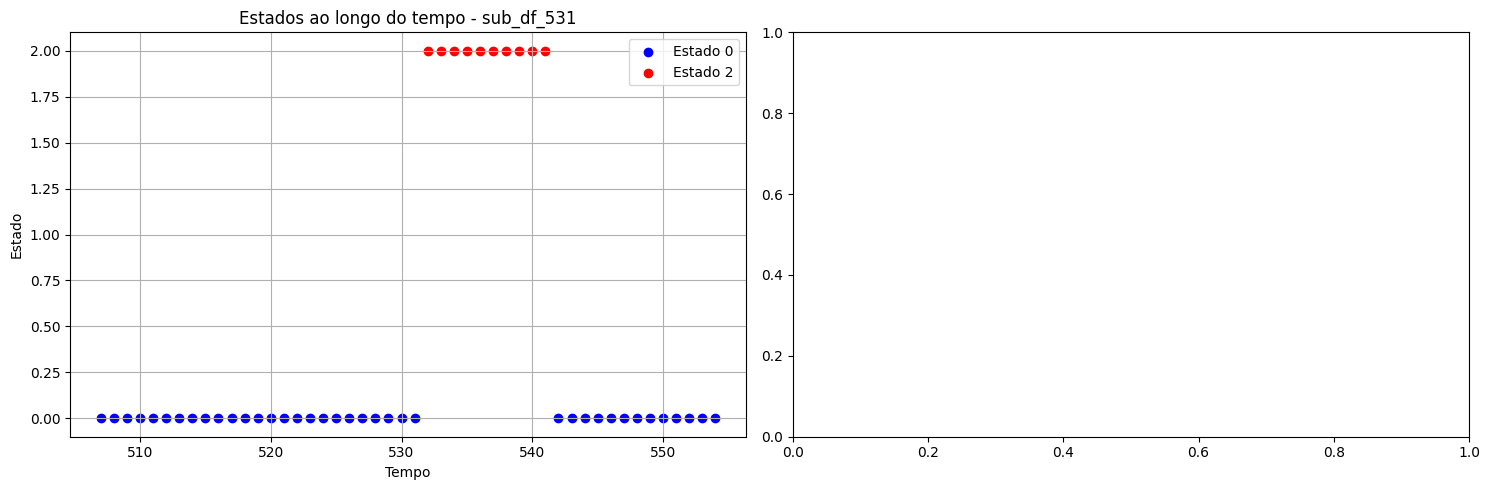

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'Estado {state}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

In [ ]:
#Estado da linha anterior
previous_state = 0
count = 0
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
state_machine = 0
for index, row in bin_data.iterrows():
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:", end=" ")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count = count + 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count = count - 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
print(count)  

0


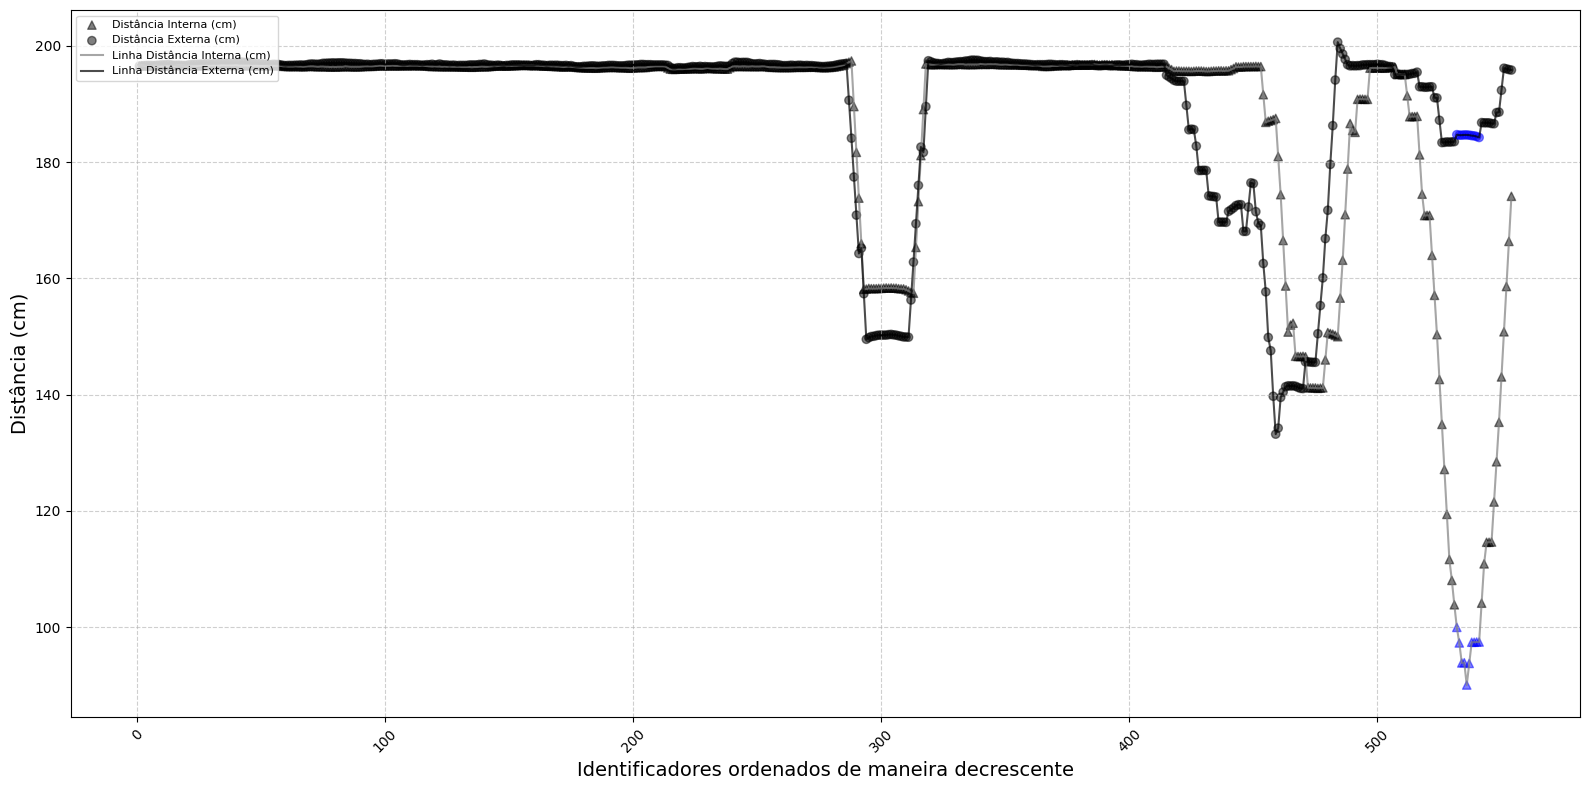

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'bin_data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data['state']]
colors_outside = [color_map[state] for state in bin_data['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data['id'], bin_data['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data['id'], bin_data['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data['id'], bin_data['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data['id'], bin_data['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [ ]:
bin_data

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,minute,second,millisecond,state_inside_sensor,state_outside_sensor,state
0,1,196.56,196.52,F0:08:D1:D0:7B:84,1601124,0,26,41,124,0,0,0
1,2,196.60,196.56,F0:08:D1:D0:7B:84,1601181,0,26,41,181,0,0,0
2,3,196.56,196.60,F0:08:D1:D0:7B:84,1601238,0,26,41,238,0,0,0
3,4,196.56,196.64,F0:08:D1:D0:7B:84,1601297,0,26,41,297,0,0,0
4,5,196.52,196.64,F0:08:D1:D0:7B:84,1601354,0,26,41,354,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
549,550,143.04,192.36,F0:08:D1:D0:7B:84,1632003,0,27,12,3,0,0,0
550,551,150.80,196.16,F0:08:D1:D0:7B:84,1632357,0,27,12,357,0,0,0
551,552,158.60,196.04,F0:08:D1:D0:7B:84,1632414,0,27,12,414,0,0,0
552,553,166.36,195.92,F0:08:D1:D0:7B:84,1632471,0,27,12,471,0,0,0


## Binarização comum

### Binarizando

In [ ]:
bin_data_comum = data
#bin_data

In [ ]:
#O que é zero é erro;
#Realmente é?
#Não é erro! Deveria, mas não é!
#bin_data = bin_data[(bin_data['distance_cm_inside'] != 0) & (bin_data['distance_cm_outside'] != 0)]
#bin_data

In [ ]:
#Binarizando
bin_data_comum['state_inside_sensor'] = bin_data_comum['distance_cm_inside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data_comum['state_outside_sensor'] = bin_data_comum['distance_cm_outside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,state_inside_sensor,state_outside_sensor
0,1,199,197,F0:08:D1:D0:7B:84,43:58,0,0,0
1,2,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0
2,3,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0
3,4,197,197,F0:08:D1:D0:7B:84,43:58,0,0,0
4,5,197,195,F0:08:D1:D0:7B:84,43:59,0,0,0
...,...,...,...,...,...,...,...,...
405,406,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0
406,407,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0
407,408,196,101,F0:08:D1:D0:7B:84,44:28,0,0,0
408,409,197,195,F0:08:D1:D0:7B:84,44:28,0,0,0


In [ ]:
def determine_state(row):
    #sem excitação
    if row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 0:
        return 0
    #tem algo na saída
    elif row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 1:
        return 1
    #tem algo na entrada
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 0:
        return 2
    #os dois estão ativados
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 1:
        return 3

bin_data_comum['state'] = bin_data_comum.apply(determine_state, axis=1)
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,state_inside_sensor,state_outside_sensor,state
0,1,199,197,F0:08:D1:D0:7B:84,43:58,0,0,0,0
1,2,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0,0
2,3,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0,0
3,4,197,197,F0:08:D1:D0:7B:84,43:58,0,0,0,0
4,5,197,195,F0:08:D1:D0:7B:84,43:59,0,0,0,0
...,...,...,...,...,...,...,...,...,...
405,406,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0
406,407,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0
407,408,196,101,F0:08:D1:D0:7B:84,44:28,0,0,0,0
408,409,197,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0


In [ ]:
print(bin_data_comum['state'].value_counts().sort_index())

state
0    276
1     26
2     85
3     23
Name: count, dtype: int64


### Plote com colorização por estado

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data_comum['state']]
colors_outside = [color_map[state] for state in bin_data_comum['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data_comum['id'], bin_data_comum['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data_comum['id'], bin_data_comum['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data_comum['id'], bin_data_comum['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data_comum['id'], bin_data_comum['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Gráfico de Distâncias Interna e Externa', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
#plt.show()
filename = f"grafico_comum_{name}.png"

# Salvando o gráfico como PNG
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()

### Tratamento para sub-dataframes

In [ ]:
#Função parece ruim!
#Seria bom analisar mais afundo e conseguir enchergar os state 3.
#Armazeno os índices de todos os eventos que possues state = 3
state_3_indices = bin_data_comum[bin_data_comum['state'] == 3].index

def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Dicionário para armazenar os sub-DataFrames
sub_dataframes = {}

# Criar sub-DataFrames para cada índice onde state = 3
for i in range(1, len(state_3_indices)):
    #armazena o índice atual que possue state = 3
    current_idx = state_3_indices[i]
    #armazena current_idx - 1
    previous_idx = state_3_indices[i - 1]
    #não pegar os mesmos ranges
    if current_idx > previous_idx + 25:
        print(current_idx)
        # Aqui você pode adicionar o que deseja fazer quando a condição for verdadeira
        sub_dataframes[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data_comum, current_idx, window=25)


297


In [ ]:
# Função para criar sub-DataFrames com base em um índice e uma janela
def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Armazenar os índices de todos os eventos onde state != 0
non_zero_state_indices = bin_data_comum[bin_data_comum['state'] != 0].index

# Dicionário para armazenar os sub-DataFrames
sub_dataframes_1 = {}

# Criar sub-DataFrames para cada índice onde state != 0
for i, current_idx in enumerate(non_zero_state_indices):
    # Verificar se o índice atual não está muito próximo do anterior
    if i == 0 or current_idx > non_zero_state_indices[i - 1] + 25:
        print(f"Criando sub-DataFrame para o índice {current_idx}")
        sub_dataframes_1[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data_comum, current_idx, window=25)

# Exibir os sub-DataFrames criados
for key, sub_df in sub_dataframes_1.items():
    print(f"\n{key}:\n{sub_df}")

Criando sub-DataFrame para o índice 37
Criando sub-DataFrame para o índice 266
Criando sub-DataFrame para o índice 363

sub_df_37:
    id  distance_cm_inside  distance_cm_outside        device_code  \
12  13                 198                  196  F0:08:D1:D0:7B:84   
13  14                 197                  196  F0:08:D1:D0:7B:84   
14  15                 199                  195  F0:08:D1:D0:7B:84   
15  16                 197                  195  F0:08:D1:D0:7B:84   
16  17                 197                  197  F0:08:D1:D0:7B:84   
17  18                 197                  195  F0:08:D1:D0:7B:84   
18  19                 197                  196  F0:08:D1:D0:7B:84   
19  20                 199                  196  F0:08:D1:D0:7B:84   
20  21                 197                  196  F0:08:D1:D0:7B:84   
21  22                 197                  195  F0:08:D1:D0:7B:84   
22  23                 197                  196  F0:08:D1:D0:7B:84   
23  24                 197   

In [ ]:
print(state_3_indices)

Index([ 98, 100, 104, 105, 106, 107, 108, 109, 110, 111, 112, 114, 115, 119,
       297, 298, 302, 303, 304, 305, 306, 310, 311],
      dtype='int64')


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}
state_map = {0: 'Inativo', 1: 'Ativ. externa', 2: 'Ativ. interna', 3: 'Ativ. dupla'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'{state_map[state]}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
#plt.show()
filename = f"grafico_comum_sub_dataframes.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()


3


In [ ]:
#Estado da linha anterior
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
#Percorrendo dicionário de eventos:
count = 0
for key, df in sub_dataframes_1.items():
  print(key)
  previous_state = 0
  state_machine = 0
  # Convertendo a coluna 'measured_at' para datetime
  #df['measured_at'] = pd.to_datetime(df['measured_at'])
  #Percorrendo cada linha de cada evento
  for index, row in df.iterrows():
    #print(row['state'], state_machine)
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count =+ 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count =- 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
  print("")
print("Quantidade de pessoas:", end=" ")
print(count)



sub_df_37

sub_df_266

sub_df_363

Quantidade de pessoas: 0


3


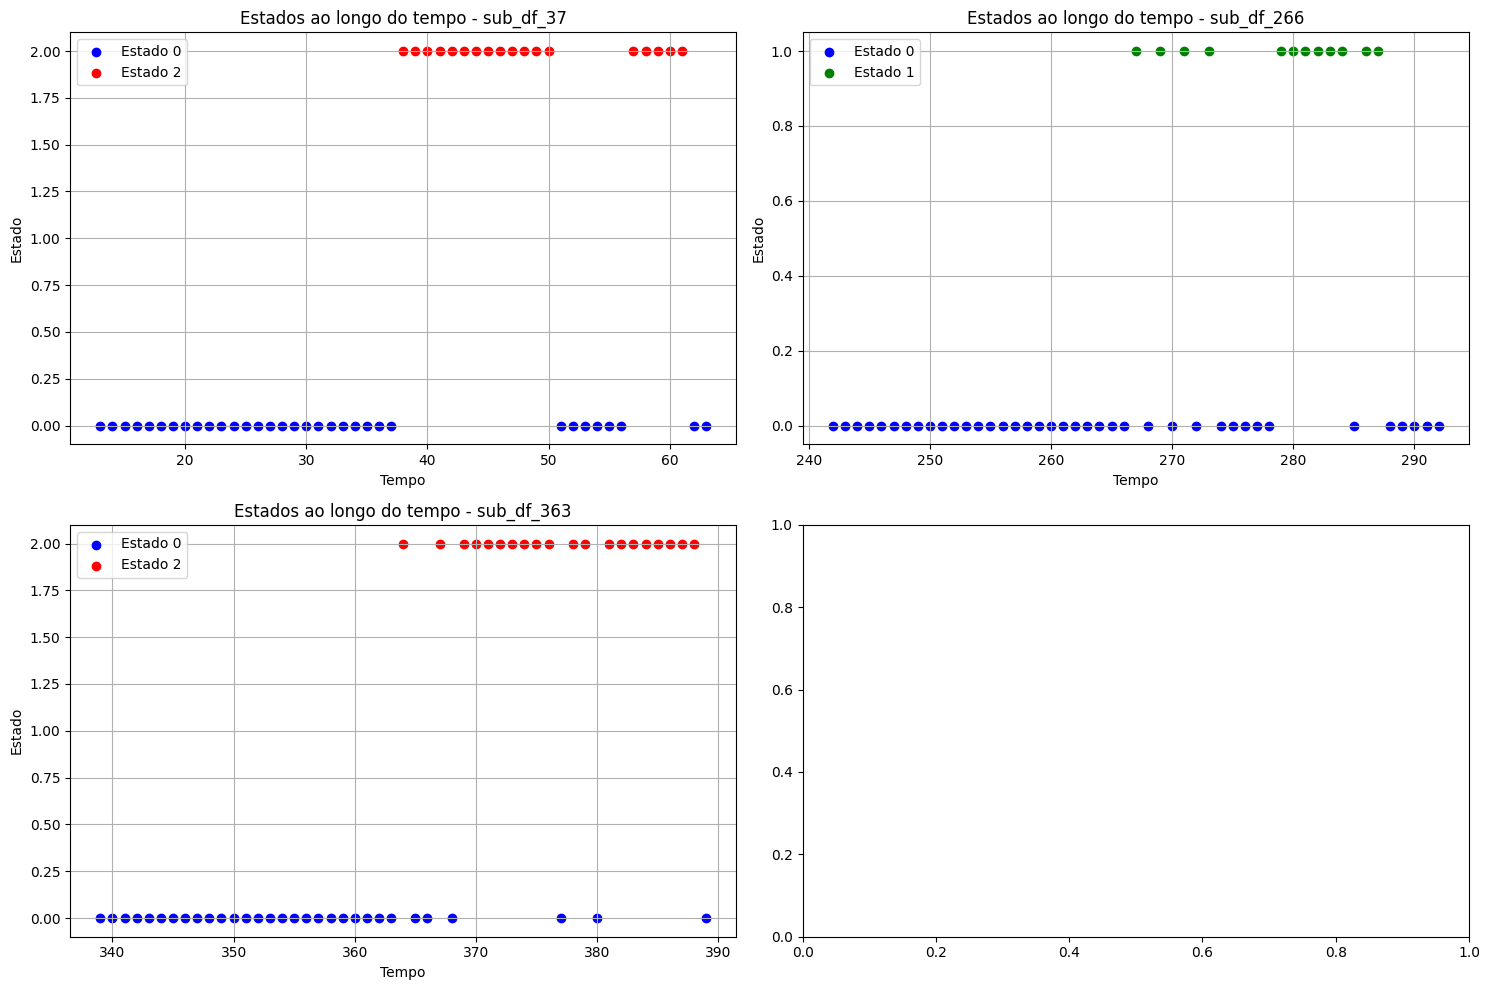

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'Estado {state}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

In [ ]:
#Estado da linha anterior
previous_state = 0
count = 0
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
state_machine = 0
for index, row in bin_data_comum.iterrows():
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:", end=" ")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count = count + 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count = count - 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
print(count)  

Evento de interesse: Evento de interesse: Alguém está entrando... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... A pessoa desistiu de entrar
Evento de interesse: Alguém está entrando... Alguém continua tentando entrar... A pessoa desistiu de entrar
Evento de interesse: Alguém está entrando... A pessoa desistiu de entrar
Evento de interesse: Alguém está saindo... Alguém continua tentando sair... A pessoa desistiu de sair
Evento de interesse: Evento de interesse: Evento de interesse: Evento de interesse: Evento de interesse: Evento de interesse: Alguém está entrando... Alguém continua tentando entrar... Alguém continua te

In [ ]:
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,state_inside_sensor,state_outside_sensor,state
0,1,199,197,F0:08:D1:D0:7B:84,43:58,0,0,0,0
1,2,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0,0
2,3,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0,0
3,4,197,197,F0:08:D1:D0:7B:84,43:58,0,0,0,0
4,5,197,195,F0:08:D1:D0:7B:84,43:59,0,0,0,0
...,...,...,...,...,...,...,...,...,...
405,406,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0
406,407,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0
407,408,196,101,F0:08:D1:D0:7B:84,44:28,0,0,0,0
408,409,197,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0


### Binarizando

In [ ]:
bin_data_comum = data
#bin_data

In [ ]:
#O que é zero é erro;
#Realmente é?
#Não é erro! Deveria, mas não é!
#bin_data = bin_data[(bin_data['distance_cm_inside'] != 0) & (bin_data['distance_cm_outside'] != 0)]
#bin_data

In [ ]:
#Binarizando
bin_data_comum['state_inside_sensor'] = bin_data_comum['distance_cm_inside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data_comum['state_outside_sensor'] = bin_data_comum['distance_cm_outside'].apply(lambda x: 1 if x <= 100 else 0)
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,state_inside_sensor,state_outside_sensor
0,1,199,197,F0:08:D1:D0:7B:84,43:58,0,0,0
1,2,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0
2,3,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0
3,4,197,197,F0:08:D1:D0:7B:84,43:58,0,0,0
4,5,197,195,F0:08:D1:D0:7B:84,43:59,0,0,0
...,...,...,...,...,...,...,...,...
405,406,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0
406,407,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0
407,408,196,101,F0:08:D1:D0:7B:84,44:28,0,0,0
408,409,197,195,F0:08:D1:D0:7B:84,44:28,0,0,0


In [ ]:
def determine_state(row):
    #sem excitação
    if row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 0:
        return 0
    #tem algo na saída
    elif row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 1:
        return 1
    #tem algo na entrada
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 0:
        return 2
    #os dois estão ativados
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 1:
        return 3

bin_data_comum['state'] = bin_data_comum.apply(determine_state, axis=1)
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,state_inside_sensor,state_outside_sensor,state
0,1,199,197,F0:08:D1:D0:7B:84,43:58,0,0,0,0
1,2,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0,0
2,3,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0,0
3,4,197,197,F0:08:D1:D0:7B:84,43:58,0,0,0,0
4,5,197,195,F0:08:D1:D0:7B:84,43:59,0,0,0,0
...,...,...,...,...,...,...,...,...,...
405,406,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0
406,407,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0
407,408,196,101,F0:08:D1:D0:7B:84,44:28,0,0,0,0
408,409,197,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0


In [ ]:
print(bin_data_comum['state'].value_counts().sort_index())

state
0    276
1     26
2     85
3     23
Name: count, dtype: int64


### Plote com colorização por estado

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data_comum['state']]
colors_outside = [color_map[state] for state in bin_data_comum['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data_comum['id'], bin_data_comum['distance_cm_inside'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data_comum['id'], bin_data_comum['distance_cm_outside'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data_comum['id'], bin_data_comum['distance_cm_inside'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data_comum['id'], bin_data_comum['distance_cm_outside'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Gráfico de Distâncias Interna e Externa', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
#plt.show()
filename = f"grafico_comum_{name}.png"

# Salvando o gráfico como PNG
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()

### Tratamento para sub-dataframes

In [ ]:
#Função parece ruim!
#Seria bom analisar mais afundo e conseguir enchergar os state 3.
#Armazeno os índices de todos os eventos que possues state = 3
state_3_indices = bin_data_comum[bin_data_comum['state'] == 3].index

def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Dicionário para armazenar os sub-DataFrames
sub_dataframes = {}

# Criar sub-DataFrames para cada índice onde state = 3
for i in range(1, len(state_3_indices)):
    #armazena o índice atual que possue state = 3
    current_idx = state_3_indices[i]
    #armazena current_idx - 1
    previous_idx = state_3_indices[i - 1]
    #não pegar os mesmos ranges
    if current_idx > previous_idx + 25:
        print(current_idx)
        # Aqui você pode adicionar o que deseja fazer quando a condição for verdadeira
        sub_dataframes[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data_comum, current_idx, window=25)


297


In [ ]:
# Função para criar sub-DataFrames com base em um índice e uma janela
def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Armazenar os índices de todos os eventos onde state != 0
non_zero_state_indices = bin_data_comum[bin_data_comum['state'] != 0].index

# Dicionário para armazenar os sub-DataFrames
sub_dataframes_1 = {}

# Criar sub-DataFrames para cada índice onde state != 0
for i, current_idx in enumerate(non_zero_state_indices):
    # Verificar se o índice atual não está muito próximo do anterior
    if i == 0 or current_idx > non_zero_state_indices[i - 1] + 25:
        print(f"Criando sub-DataFrame para o índice {current_idx}")
        sub_dataframes_1[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data_comum, current_idx, window=25)

# Exibir os sub-DataFrames criados
for key, sub_df in sub_dataframes_1.items():
    print(f"\n{key}:\n{sub_df}")

Criando sub-DataFrame para o índice 37
Criando sub-DataFrame para o índice 266
Criando sub-DataFrame para o índice 363

sub_df_37:
    id  distance_cm_inside  distance_cm_outside        device_code  \
12  13                 198                  196  F0:08:D1:D0:7B:84   
13  14                 197                  196  F0:08:D1:D0:7B:84   
14  15                 199                  195  F0:08:D1:D0:7B:84   
15  16                 197                  195  F0:08:D1:D0:7B:84   
16  17                 197                  197  F0:08:D1:D0:7B:84   
17  18                 197                  195  F0:08:D1:D0:7B:84   
18  19                 197                  196  F0:08:D1:D0:7B:84   
19  20                 199                  196  F0:08:D1:D0:7B:84   
20  21                 197                  196  F0:08:D1:D0:7B:84   
21  22                 197                  195  F0:08:D1:D0:7B:84   
22  23                 197                  196  F0:08:D1:D0:7B:84   
23  24                 197   

In [ ]:
print(state_3_indices)

Index([ 98, 100, 104, 105, 106, 107, 108, 109, 110, 111, 112, 114, 115, 119,
       297, 298, 302, 303, 304, 305, 306, 310, 311],
      dtype='int64')


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}
state_map = {0: 'Inativo', 1: 'Ativ. externa', 2: 'Ativ. interna', 3: 'Ativ. dupla'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'{state_map[state]}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
#plt.show()
filename = f"grafico_comum_sub_dataframes.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()


3


In [ ]:
#Estado da linha anterior
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
#Percorrendo dicionário de eventos:
count = 0
for key, df in sub_dataframes_1.items():
  print(key)
  previous_state = 0
  state_machine = 0
  # Convertendo a coluna 'measured_at' para datetime
  #df['measured_at'] = pd.to_datetime(df['measured_at'])
  #Percorrendo cada linha de cada evento
  for index, row in df.iterrows():
    #print(row['state'], state_machine)
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count =+ 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count =- 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
  print("")
print("Quantidade de pessoas:", end=" ")
print(count)



sub_df_37

sub_df_266

sub_df_363

Quantidade de pessoas: 0


3


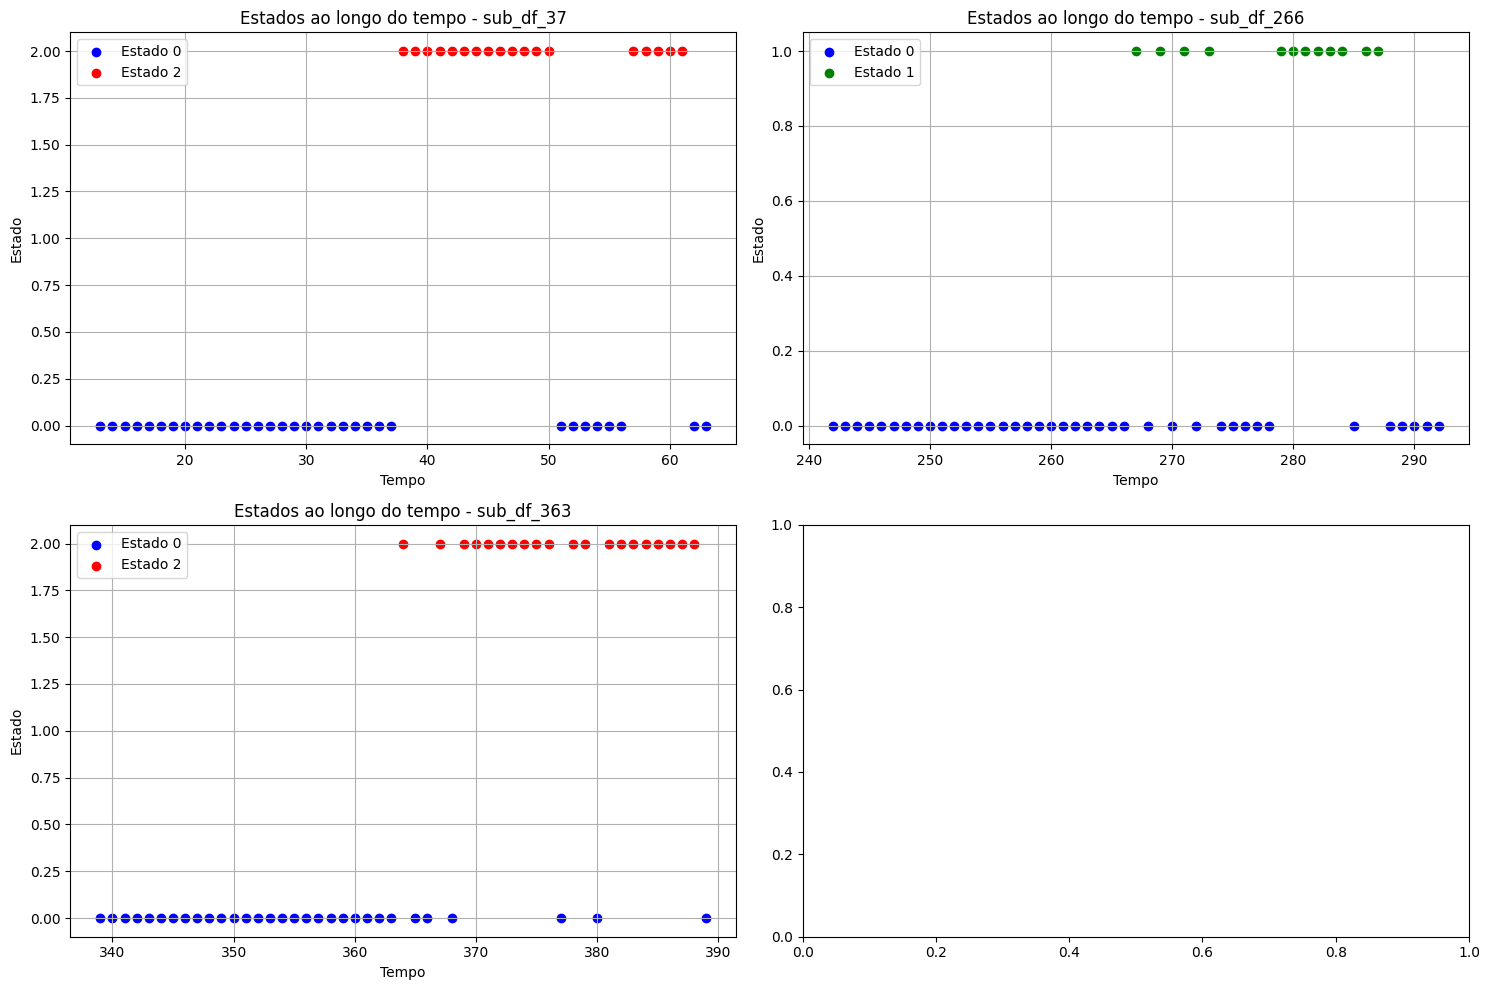

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'Estado {state}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

In [ ]:
#Estado da linha anterior
previous_state = 0
count = 0
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
state_machine = 0
for index, row in bin_data_comum.iterrows():
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:", end=" ")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count = count + 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count = count - 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
print(count)  

Evento de interesse: Evento de interesse: Alguém está entrando... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... Alguém continua tentando entrar... A pessoa desistiu de entrar
Evento de interesse: Alguém está entrando... Alguém continua tentando entrar... A pessoa desistiu de entrar
Evento de interesse: Alguém está entrando... A pessoa desistiu de entrar
Evento de interesse: Alguém está saindo... Alguém continua tentando sair... A pessoa desistiu de sair
Evento de interesse: Evento de interesse: Evento de interesse: Evento de interesse: Evento de interesse: Evento de interesse: Alguém está entrando... Alguém continua tentando entrar... Alguém continua te

In [ ]:
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,state_inside_sensor,state_outside_sensor,state
0,1,199,197,F0:08:D1:D0:7B:84,43:58,0,0,0,0
1,2,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0,0
2,3,197,196,F0:08:D1:D0:7B:84,43:58,0,0,0,0
3,4,197,197,F0:08:D1:D0:7B:84,43:58,0,0,0,0
4,5,197,195,F0:08:D1:D0:7B:84,43:59,0,0,0,0
...,...,...,...,...,...,...,...,...,...
405,406,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0
406,407,198,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0
407,408,196,101,F0:08:D1:D0:7B:84,44:28,0,0,0,0
408,409,197,195,F0:08:D1:D0:7B:84,44:28,0,0,0,0


## Binarização pós WMAF (Tentativa de caracterização através da janela do evento)

In [502]:
bin_data_comum = df1
#bin_data

In [503]:
bin_data_comum = bin_data_comum.dropna()
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm,inside_smooth,outside_smooth,soma_smooth,inside_smooth_classification,outside_smooth_classification
24,25,4.0,197.0,1111123,1.753190e+09,1.753190e+09,18,31,123,201.0,4.000000,196.433846,200.802877,Nada,Nada
25,26,4.0,197.0,1111169,1.753190e+09,1.753190e+09,18,31,169,201.0,4.000000,196.483077,200.828702,Nada,Nada
26,27,4.0,197.0,1111215,1.753190e+09,1.753190e+09,18,31,215,201.0,4.000000,196.529231,200.839817,Nada,Nada
27,28,4.0,197.0,1111261,1.753190e+09,1.753190e+09,18,31,261,201.0,4.000000,196.572308,200.832952,Nada,Nada
28,29,4.0,197.0,1111309,1.753190e+09,1.753190e+09,18,31,309,201.0,4.000000,196.612308,200.860739,Nada,Nada
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0,196.553846,196.160000,393.078451,Nada,Nada
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0,196.507692,196.224615,393.207097,Nada,Nada
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0,196.541538,196.289231,393.349740,Nada,Nada
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0,196.652308,196.273846,393.506381,Nada,Nada


In [504]:
print(bin_data_comum.isna().sum())

id                               0
distance_cm_inside               0
distance_cm_outside              0
measured_at                      0
epoch_start                      0
epoch_end                        0
minute                           0
second                           0
millisecond                      0
soma_distancias_cm               0
inside_smooth                    0
outside_smooth                   0
soma_smooth                      0
inside_smooth_classification     0
outside_smooth_classification    0
dtype: int64


In [505]:
#Estados definidos através da fusão de dados
def determine_initial_state(row):
    #porta fechada
    if row['soma_distancias_cm'] <= 210 and row['soma_distancias_cm'] >= 190:
        return 0
    #porta aberta
    else:
        return 1

bin_data_comum['state'] = bin_data_comum.apply(determine_initial_state, axis=1)
bin_data_comum

/tmp/ipykernel_25750/2786069146.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_data_comum['state'] = bin_data_comum.apply(determine_initial_state, axis=1)


,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm,inside_smooth,outside_smooth,soma_smooth,inside_smooth_classification,outside_smooth_classification,state
24,25,4.0,197.0,1111123,1.753190e+09,1.753190e+09,18,31,123,201.0,4.000000,196.433846,200.802877,Nada,Nada,0
25,26,4.0,197.0,1111169,1.753190e+09,1.753190e+09,18,31,169,201.0,4.000000,196.483077,200.828702,Nada,Nada,0
26,27,4.0,197.0,1111215,1.753190e+09,1.753190e+09,18,31,215,201.0,4.000000,196.529231,200.839817,Nada,Nada,0
27,28,4.0,197.0,1111261,1.753190e+09,1.753190e+09,18,31,261,201.0,4.000000,196.572308,200.832952,Nada,Nada,0
28,29,4.0,197.0,1111309,1.753190e+09,1.753190e+09,18,31,309,201.0,4.000000,196.612308,200.860739,Nada,Nada,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,224,197.0,196.0,1120766,1.753190e+09,1.753190e+09,18,40,766,393.0,196.553846,196.160000,393.078451,Nada,Nada,1
224,225,196.0,197.0,1120823,1.753190e+09,1.753190e+09,18,40,823,393.0,196.507692,196.224615,393.207097,Nada,Nada,1
225,226,197.0,197.0,1120880,1.753190e+09,1.753190e+09,18,40,880,394.0,196.541538,196.289231,393.349740,Nada,Nada,1
226,227,198.0,196.0,1120938,1.753190e+09,1.753190e+09,18,40,938,394.0,196.652308,196.273846,393.506381,Nada,Nada,1


In [506]:
pd.options.display.max_rows = 200


In [507]:
bin_data_comum.tail(200)

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm,inside_smooth,outside_smooth,soma_smooth,inside_smooth_classification,outside_smooth_classification,state
28,29,4.0,197.0,1111309,1.753190e+09,1.753190e+09,18,31,309,201.0,4.000000,196.612308,200.860739,Nada,Nada,0
29,30,4.0,197.0,1111355,1.753190e+09,1.753190e+09,18,31,355,201.0,4.000000,196.652308,200.923178,Nada,Nada,0
30,31,4.0,196.0,1111401,1.753190e+09,1.753190e+09,18,31,401,200.0,4.000000,196.612308,200.911736,Nada,Nada,0
31,32,4.0,197.0,1111447,1.753190e+09,1.753190e+09,18,31,447,201.0,4.000000,196.652308,200.972540,Nada,Nada,0
32,33,4.0,197.0,1111493,1.753190e+09,1.753190e+09,18,31,493,201.0,4.000000,196.689231,200.928408,Nada,Nada,0
33,34,4.0,197.0,1111539,1.753190e+09,1.753190e+09,18,31,539,201.0,4.000000,196.723077,200.925466,Nada,Nada,0
34,35,4.0,197.0,1111585,1.753190e+09,1.753190e+09,18,31,585,201.0,4.000000,196.753846,200.764956,Nada,Nada,0
35,36,4.0,197.0,1111631,1.753190e+09,1.753190e+09,18,31,631,201.0,4.000000,196.784615,200.679961,Nada,Nada,0
36,37,4.0,197.0,1111677,1.753190e+09,1.753190e+09,18,31,677,201.0,4.000000,196.812308,200.670481,Nada,Nada,0
37,38,4.0,197.0,1111722,1.753190e+09,1.753190e+09,18,31,722,201.0,4.000000,196.836923,200.649559,Nada,Nada,0


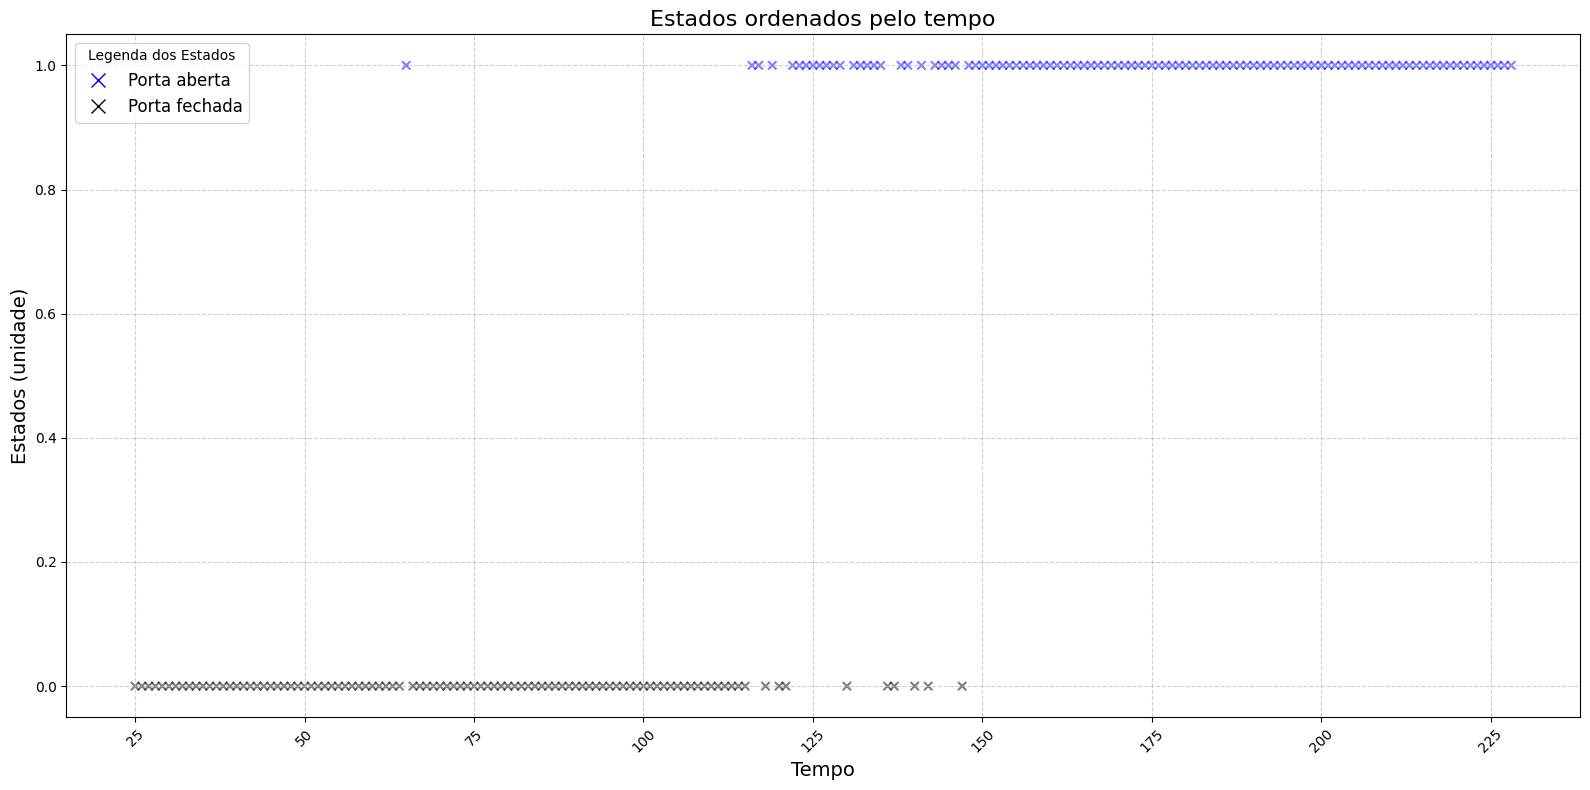

In [508]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  
    1: 'blue'
}

colors = [color_map[state] for state in bin_data_comum['state']]
plt.figure(figsize=(16, 8))
plt.scatter(bin_data_comum['id'], bin_data_comum['state'], c=colors, label='Ativação outside', alpha=0.5, marker="x")

legend_elements = [
    Line2D([0], [0], marker='x', color='w', label='Porta aberta',
           markerfacecolor='blue', markeredgecolor='blue', markersize=10),
    Line2D([0], [0], marker='x', color='w', label='Porta fechada',
           markerfacecolor='black', markeredgecolor='black', markersize=10)
]

# Adicionar título e legendas
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Estados (unidade)', fontsize=14)
plt.legend(handles=legend_elements, loc='upper left', fontsize=12, title='Legenda dos Estados')
plt.title('Estados ordenados pelo tempo', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
filename = f"statemap_{name}.png"

# Salvando o gráfico como PNG
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [509]:
bin_data_comum = bin_data_comum[bin_data_comum['state'] == 1]

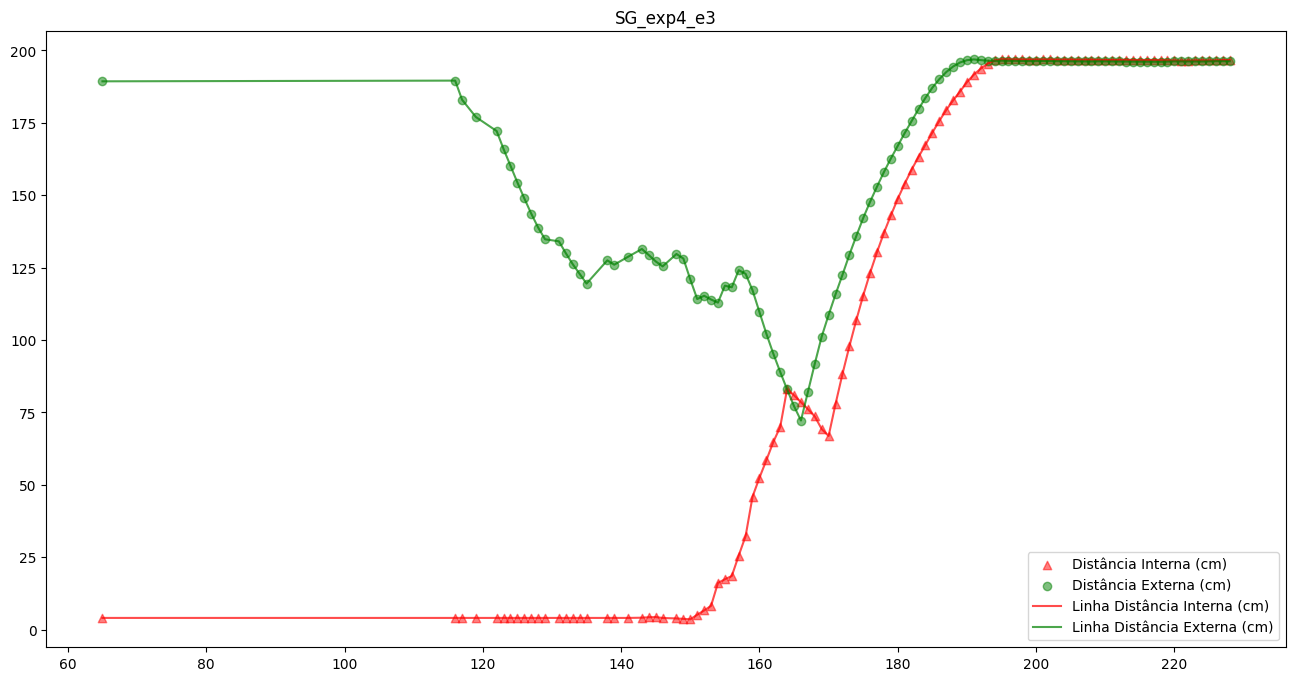

In [510]:
plt.figure(figsize=(16, 8))
plt.scatter(bin_data_comum['id'], bin_data_comum['inside_smooth'], label='Distância Interna (cm)', alpha=0.5, marker='^', c='red')
plt.scatter(bin_data_comum['id'], bin_data_comum['outside_smooth'], label='Distância Externa (cm)', alpha=0.5, c='green')
plt.plot(bin_data_comum['id'], bin_data_comum['inside_smooth'], linestyle='-', color='red', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data_comum['id'], bin_data_comum['outside_smooth'], linestyle='-', color='green', alpha=0.7, label='Linha Distância Externa (cm)')
plt.legend()
plt.title(f"SG_{name}")
filename = f"SG_{name}.png"

# Salvando o gráfico como PNG
#plt.gca().invert_yaxis()
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [511]:
bin_data_comum['state_inside_sensor'] = bin_data_comum['inside_smooth'].apply(lambda x: 1 if x <= 100 else 0)
bin_data_comum['state_outside_sensor'] = bin_data_comum['outside_smooth'].apply(lambda x: 1 if x <= 100 else 0)
bin_data_comum

/tmp/ipykernel_25750/4280024585.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_data_comum['state_inside_sensor'] = bin_data_comum['inside_smooth'].apply(lambda x: 1 if x <= 100 else 0)
/tmp/ipykernel_25750/4280024585.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_data_comum['state_outside_sensor'] = bin_data_comum['outside_smooth'].apply(lambda x: 1 if x <= 100 else 0)


,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,soma_distancias_cm,inside_smooth,outside_smooth,soma_smooth,inside_smooth_classification,outside_smooth_classification,state,state_inside_sensor,state_outside_sensor
64,65,4.0,104.0,1112957,1.753190e+09,1.753190e+09,18,32,957,108.0,4.000000,189.313846,190.326577,Nada,Vale outside_smooth,1,1,0
115,116,4.0,107.0,1115300,1.753190e+09,1.753190e+09,18,35,300,111.0,4.000000,189.560000,173.083034,Nada,Nada,1,1,0
116,117,4.0,107.0,1115339,1.753190e+09,1.753190e+09,18,35,339,111.0,4.000000,182.950769,166.029421,Nada,Nada,1,1,0
118,119,4.0,104.0,1115424,1.753190e+09,1.753190e+09,18,35,424,108.0,4.000000,176.978462,150.100360,Nada,Nada,1,1,0
121,122,4.0,101.0,1115557,1.753190e+09,1.753190e+09,18,35,557,105.0,4.000000,172.138462,128.912063,Nada,Nada,1,1,0
122,123,4.0,101.0,1115597,1.753190e+09,1.753190e+09,18,35,597,105.0,4.000000,165.923077,125.876103,Nada,Nada,1,1,0
123,124,4.0,103.0,1115638,1.753190e+09,1.753190e+09,18,35,638,107.0,4.000000,160.156923,123.663289,Nada,Nada,1,1,0
124,125,4.0,99.0,1115678,1.753190e+09,1.753190e+09,18,35,678,103.0,4.000000,154.369231,122.991500,Nada,Nada,1,1,0
125,126,4.0,99.0,1115719,1.753190e+09,1.753190e+09,18,35,719,103.0,4.000000,148.880000,118.271004,Nada,Nada,1,1,0
126,127,4.0,98.0,1115759,1.753190e+09,1.753190e+09,18,35,759,102.0,4.000000,143.615385,110.494279,Nada,Nada,1,1,0


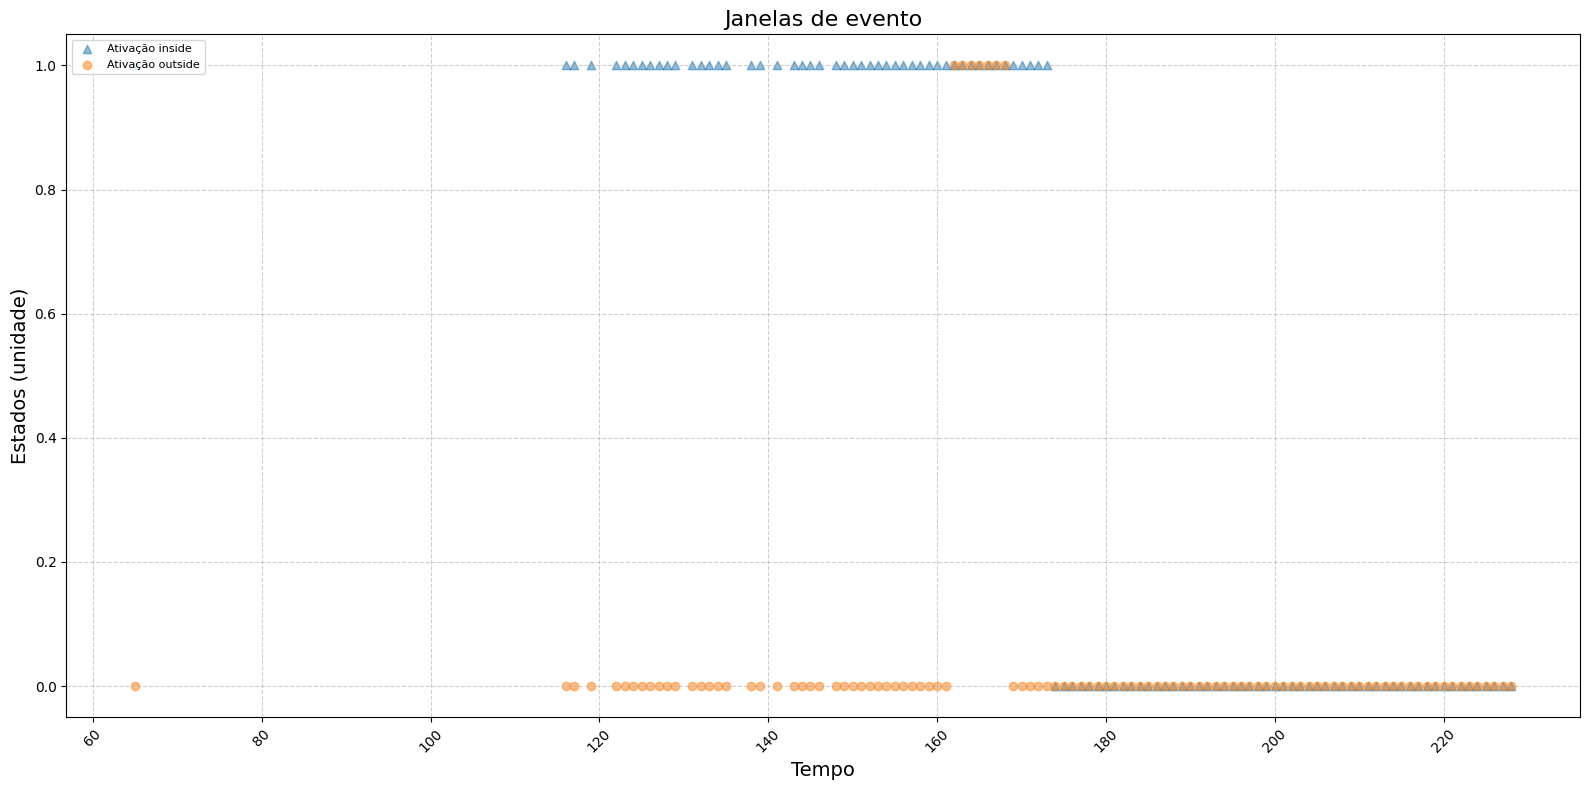

In [512]:
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data_comum['id'], bin_data_comum['state_inside_sensor'], label='Ativação inside', alpha=0.5, marker='^')
plt.scatter(bin_data_comum['id'], bin_data_comum['state_outside_sensor'], label='Ativação outside', alpha=0.5)
#plt.scatter(bin_data_comum['id'], bin_data_comum['state'], c=colors, label='Ativação outside', alpha=0.5, marker="x")

# Adicionar as linhas de conexão
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['inside_smooth'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['outside_smooth'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Estados (unidade)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Janelas de evento', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
filename = f"fluxo_{name}.png"

# Salvando o gráfico como PNG
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [513]:
bin_data_comum = bin_data_comum.reset_index(drop=True)
bin_data_comum['id'] = bin_data_comum.index

In [514]:
bin_data_comum = bin_data_comum[(bin_data_comum['state_inside_sensor'] != 0) | (bin_data_comum['state_outside_sensor'] != 0)]

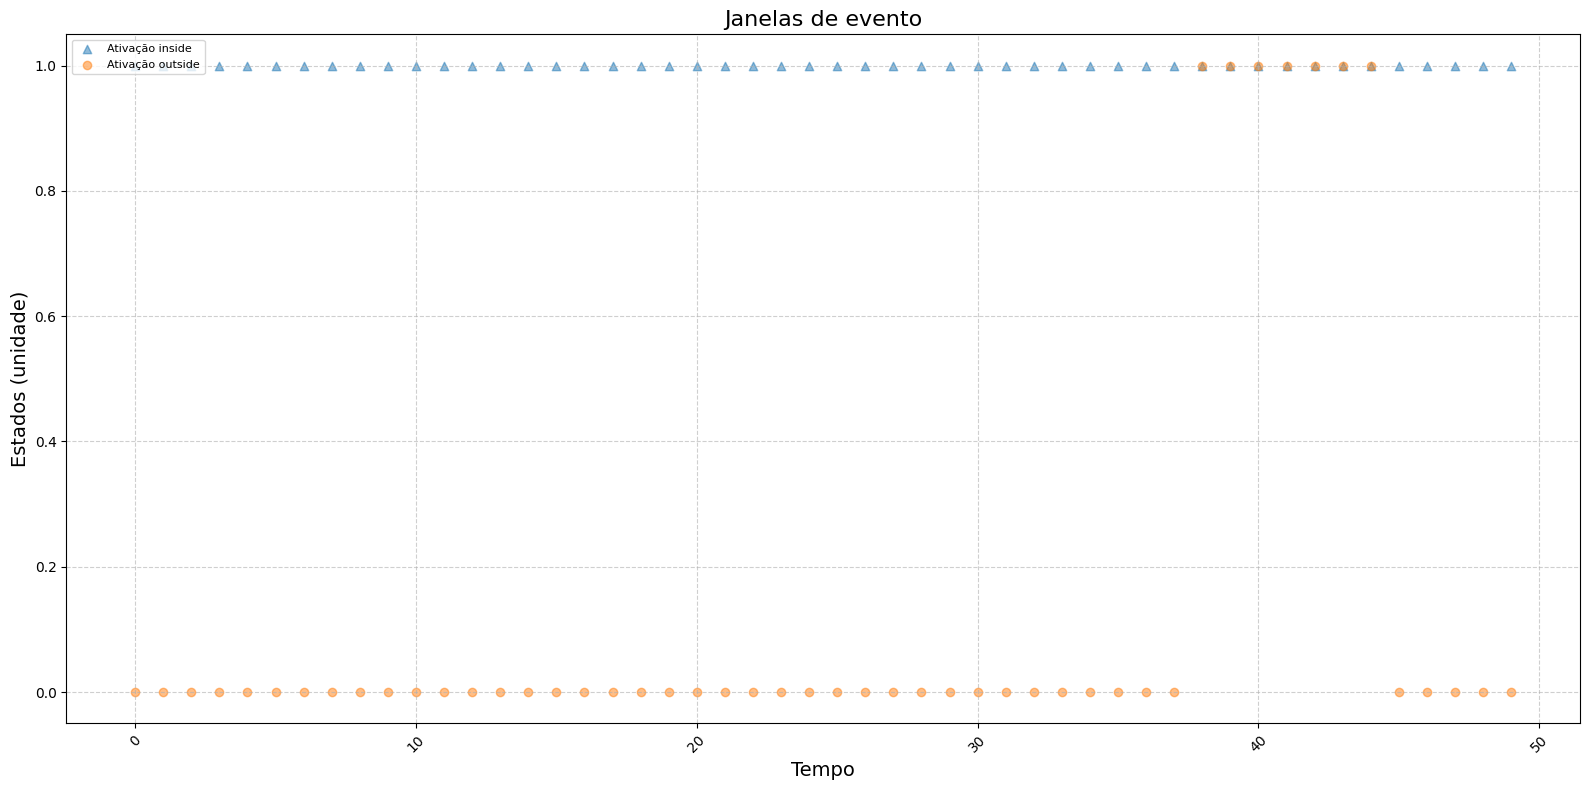

In [515]:
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data_comum['id'], bin_data_comum['state_inside_sensor'], label='Ativação inside', alpha=0.5, marker='^')
plt.scatter(bin_data_comum['id'], bin_data_comum['state_outside_sensor'], label='Ativação outside', alpha=0.5)
#plt.scatter(bin_data_comum['id'], bin_data_comum['state'], c=colors, label='Ativação outside', alpha=0.5, marker="x")

# Adicionar as linhas de conexão
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['inside_smooth'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['outside_smooth'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Estados (unidade)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Janelas de evento', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
filename = f"fluxo_{name}.png"

# Salvando o gráfico como PNG
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [516]:
saltos = bin_data_comum['id'] > (bin_data_comum['id'].shift(1) + 1)
saltos = saltos.fillna(True)
grupos = saltos.cumsum()
sub_dataframes = {group_id: data for group_id, data in bin_data_comum.groupby(grupos)}


In [517]:
print(len(sub_dataframes))

1


In [518]:
for grupo_id, df_bloco in sub_dataframes.items():
    if len(df_bloco) < 2:
        print(f"Bloco {grupo_id}: Ignorado (muito curto).")
        continue
    primeira_linha = df_bloco.iloc[0]
    ultima_linha = df_bloco.iloc[-1]
    condicao_evento = (primeira_linha['state_inside_sensor'] != ultima_linha['state_inside_sensor'] and primeira_linha['state_outside_sensor'] != ultima_linha['state_outside_sensor'])
    if(condicao_evento):
        if(primeira_linha['state_inside_sensor'] == 1):
            print("Alguém saiu")
        else:
            print("Alguém entrou")
    else:
        print("Falso evento")
        continue

Falso evento


## Binarização pós WMAF (Tentativa de caracterização por inicio e fim do evento)

In [675]:
bin_data_comum = data
#bin_data

In [676]:
bin_data_comum = bin_data_comum.dropna()
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,inside_smooth,outside_smooth,inside_smooth_classification,outside_smooth_classification
17,18,196.0,198.0,2238989,1.750193e+09,1.750193e+09,37,18,989,196.181287,197.263158,Nada,Nada
18,19,196.0,198.0,2239046,1.750193e+09,1.750193e+09,37,19,46,196.140351,197.350877,Nada,Nada
19,20,196.0,197.0,2239103,1.750193e+09,1.750193e+09,37,19,103,196.105263,197.327485,Nada,Nada
20,21,197.0,197.0,2239159,1.750193e+09,1.750193e+09,37,19,159,196.187135,197.304094,Nada,Nada
21,22,196.0,197.0,2239217,1.750193e+09,1.750193e+09,37,19,217,196.157895,197.286550,Nada,Nada
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,302,197.0,197.0,2250231,1.750193e+09,1.750193e+09,37,30,231,196.725146,197.210526,Nada,Nada
302,303,197.0,198.0,2250289,1.750193e+09,1.750193e+09,37,30,289,196.760234,197.298246,Nada,Nada
303,304,196.0,197.0,2250346,1.750193e+09,1.750193e+09,37,30,346,196.684211,197.280702,Nada,Nada
304,305,196.0,198.0,2250404,1.750193e+09,1.750193e+09,37,30,404,196.614035,197.368421,Nada,Nada


In [677]:
print(bin_data_comum.isna().sum())

id                               0
distance_cm_inside               0
distance_cm_outside              0
measured_at                      0
epoch_start                      0
epoch_end                        0
minute                           0
second                           0
millisecond                      0
inside_smooth                    0
outside_smooth                   0
inside_smooth_classification     0
outside_smooth_classification    0
dtype: int64


In [678]:
#Binarizando
bin_data_comum['state_inside_sensor'] = bin_data_comum['inside_smooth'].apply(lambda x: 1 if x <= 190 else 0)
bin_data_comum['state_outside_sensor'] = bin_data_comum['outside_smooth'].apply(lambda x: 1 if x <= 190 else 0)
bin_data_comum

/tmp/ipykernel_2814/822456308.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_data_comum['state_inside_sensor'] = bin_data_comum['inside_smooth'].apply(lambda x: 1 if x <= 190 else 0)
/tmp/ipykernel_2814/822456308.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_data_comum['state_outside_sensor'] = bin_data_comum['outside_smooth'].apply(lambda x: 1 if x <= 190 else 0)


,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,inside_smooth,outside_smooth,inside_smooth_classification,outside_smooth_classification,state_inside_sensor,state_outside_sensor
17,18,196.0,198.0,2238989,1.750193e+09,1.750193e+09,37,18,989,196.181287,197.263158,Nada,Nada,0,0
18,19,196.0,198.0,2239046,1.750193e+09,1.750193e+09,37,19,46,196.140351,197.350877,Nada,Nada,0,0
19,20,196.0,197.0,2239103,1.750193e+09,1.750193e+09,37,19,103,196.105263,197.327485,Nada,Nada,0,0
20,21,197.0,197.0,2239159,1.750193e+09,1.750193e+09,37,19,159,196.187135,197.304094,Nada,Nada,0,0
21,22,196.0,197.0,2239217,1.750193e+09,1.750193e+09,37,19,217,196.157895,197.286550,Nada,Nada,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,302,197.0,197.0,2250231,1.750193e+09,1.750193e+09,37,30,231,196.725146,197.210526,Nada,Nada,0,0
302,303,197.0,198.0,2250289,1.750193e+09,1.750193e+09,37,30,289,196.760234,197.298246,Nada,Nada,0,0
303,304,196.0,197.0,2250346,1.750193e+09,1.750193e+09,37,30,346,196.684211,197.280702,Nada,Nada,0,0
304,305,196.0,198.0,2250404,1.750193e+09,1.750193e+09,37,30,404,196.614035,197.368421,Nada,Nada,0,0


In [679]:
def determine_state(row):
    #porta aberta
    if row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 0:
        return 1
    #alguem do lado de fora entrando
    elif row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 1:
        return 2
    #porta fechada
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 0:
        return 0
    #alguem na entrada da porta(estado redundante não deve alterar a máquina de estados)
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 1:
        return 3

bin_data_comum['state'] = bin_data_comum.apply(determine_state, axis=1)


/tmp/ipykernel_2814/76069830.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_data_comum['state'] = bin_data_comum.apply(determine_state, axis=1)


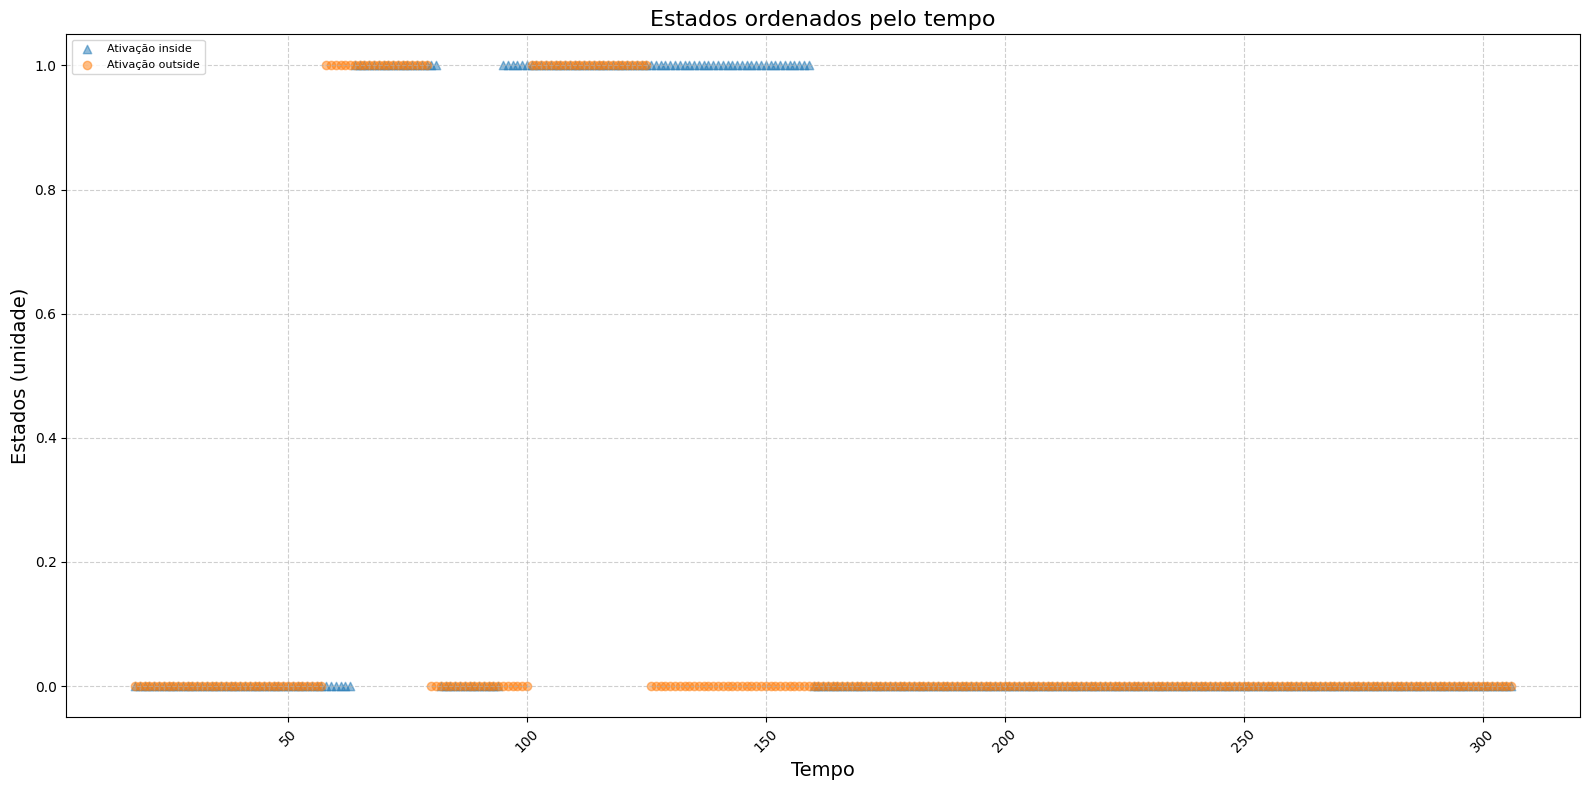

In [680]:
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data_comum['id'], bin_data_comum['state_inside_sensor'], label='Ativação inside', alpha=0.5, marker='^')
plt.scatter(bin_data_comum['id'], bin_data_comum['state_outside_sensor'], label='Ativação outside', alpha=0.5)
#plt.scatter(bin_data_comum['id'], bin_data_comum['state'], c=colors, label='Ativação outside', alpha=0.5, marker="x")

# Adicionar as linhas de conexão
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['inside_smooth'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['outside_smooth'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Estados (unidade)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Estados ordenados pelo tempo', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
filename = f"fluxo_{name}.png"

# Salvando o gráfico como PNG
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Nova binarização pós smoothing

### Binarizando

In [47]:
bin_data_comum = data
#bin_data

In [48]:
bin_data_comum = bin_data_comum.dropna()
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,inside_smooth,outside_smooth,inside_smooth_classification,outside_smooth_classification,state_inside_sensor,state_outside_sensor
17,18,198.0,196.0,2206985,1.750193e+09,1.750193e+09,36,46,985,197.204678,196.795322,Nada,Nada,0,0
18,19,196.0,197.0,2207043,1.750193e+09,1.750193e+09,36,47,43,197.076023,196.807018,Nada,Nada,0,0
19,20,197.0,197.0,2207100,1.750193e+09,1.750193e+09,36,47,100,197.058480,196.818713,Nada,Nada,0,0
20,21,197.0,196.0,2207158,1.750193e+09,1.750193e+09,36,47,158,197.035088,196.730994,Nada,Nada,0,0
21,22,197.0,197.0,2207215,1.750193e+09,1.750193e+09,36,47,215,197.017544,196.748538,Nada,Nada,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,242,197.0,198.0,2219769,1.750193e+09,1.750193e+09,36,59,769,197.046784,197.011696,Nada,Nada,0,0
242,243,197.0,197.0,2219828,1.750193e+09,1.750193e+09,36,59,828,197.046784,197.005848,Nada,Nada,0,0
243,244,196.0,198.0,2219885,1.750193e+09,1.750193e+09,36,59,885,196.941520,197.105263,Nada,Nada,0,0
244,245,196.0,197.0,2219942,1.750193e+09,1.750193e+09,36,59,942,196.836257,197.099415,Nada,Nada,0,0


In [50]:
print(bin_data_comum.isna().sum())

id                               0
distance_cm_inside               0
distance_cm_outside              0
measured_at                      0
epoch_start                      0
epoch_end                        0
minute                           0
second                           0
millisecond                      0
inside_smooth                    0
outside_smooth                   0
inside_smooth_classification     0
outside_smooth_classification    0
state_inside_sensor              0
state_outside_sensor             0
dtype: int64


In [51]:
#Binarizando
bin_data_comum['state_inside_sensor'] = bin_data_comum['inside_smooth'].apply(lambda x: 1 if x <= 180 else 0)
bin_data_comum['state_outside_sensor'] = bin_data_comum['outside_smooth'].apply(lambda x: 1 if x <= 180 else 0)
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,inside_smooth,outside_smooth,inside_smooth_classification,outside_smooth_classification,state_inside_sensor,state_outside_sensor
17,18,198.0,196.0,2206985,1.750193e+09,1.750193e+09,36,46,985,197.204678,196.795322,Nada,Nada,0,0
18,19,196.0,197.0,2207043,1.750193e+09,1.750193e+09,36,47,43,197.076023,196.807018,Nada,Nada,0,0
19,20,197.0,197.0,2207100,1.750193e+09,1.750193e+09,36,47,100,197.058480,196.818713,Nada,Nada,0,0
20,21,197.0,196.0,2207158,1.750193e+09,1.750193e+09,36,47,158,197.035088,196.730994,Nada,Nada,0,0
21,22,197.0,197.0,2207215,1.750193e+09,1.750193e+09,36,47,215,197.017544,196.748538,Nada,Nada,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,242,197.0,198.0,2219769,1.750193e+09,1.750193e+09,36,59,769,197.046784,197.011696,Nada,Nada,0,0
242,243,197.0,197.0,2219828,1.750193e+09,1.750193e+09,36,59,828,197.046784,197.005848,Nada,Nada,0,0
243,244,196.0,198.0,2219885,1.750193e+09,1.750193e+09,36,59,885,196.941520,197.105263,Nada,Nada,0,0
244,245,196.0,197.0,2219942,1.750193e+09,1.750193e+09,36,59,942,196.836257,197.099415,Nada,Nada,0,0


In [ ]:
def determine_state(row):
    #porta aberta
    if row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 0:
        return 0
    #alguem do lado de fora entrando
    elif row['state_inside_sensor'] == 0 and row['state_outside_sensor'] == 1:
        return 1
    #porta fechada
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 0:
        return 2
    #alguem na entrada da porta(estado redundante não deve alterar a máquina de estados)
    elif row['state_inside_sensor'] == 1 and row['state_outside_sensor'] == 1:
        return 3

bin_data_comum['state'] = bin_data_comum.apply(determine_state, axis=1)


In [53]:
bin_data_comum.to_csv("teste.csv")

In [54]:
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,measured_at,epoch_start,epoch_end,minute,second,millisecond,inside_smooth,outside_smooth,inside_smooth_classification,outside_smooth_classification,state_inside_sensor,state_outside_sensor,state
17,18,198.0,196.0,2206985,1.750193e+09,1.750193e+09,36,46,985,197.204678,196.795322,Nada,Nada,0,0,0
18,19,196.0,197.0,2207043,1.750193e+09,1.750193e+09,36,47,43,197.076023,196.807018,Nada,Nada,0,0,0
19,20,197.0,197.0,2207100,1.750193e+09,1.750193e+09,36,47,100,197.058480,196.818713,Nada,Nada,0,0,0
20,21,197.0,196.0,2207158,1.750193e+09,1.750193e+09,36,47,158,197.035088,196.730994,Nada,Nada,0,0,0
21,22,197.0,197.0,2207215,1.750193e+09,1.750193e+09,36,47,215,197.017544,196.748538,Nada,Nada,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,242,197.0,198.0,2219769,1.750193e+09,1.750193e+09,36,59,769,197.046784,197.011696,Nada,Nada,0,0,0
242,243,197.0,197.0,2219828,1.750193e+09,1.750193e+09,36,59,828,197.046784,197.005848,Nada,Nada,0,0,0
243,244,196.0,198.0,2219885,1.750193e+09,1.750193e+09,36,59,885,196.941520,197.105263,Nada,Nada,0,0,0
244,245,196.0,197.0,2219942,1.750193e+09,1.750193e+09,36,59,942,196.836257,197.099415,Nada,Nada,0,0,0


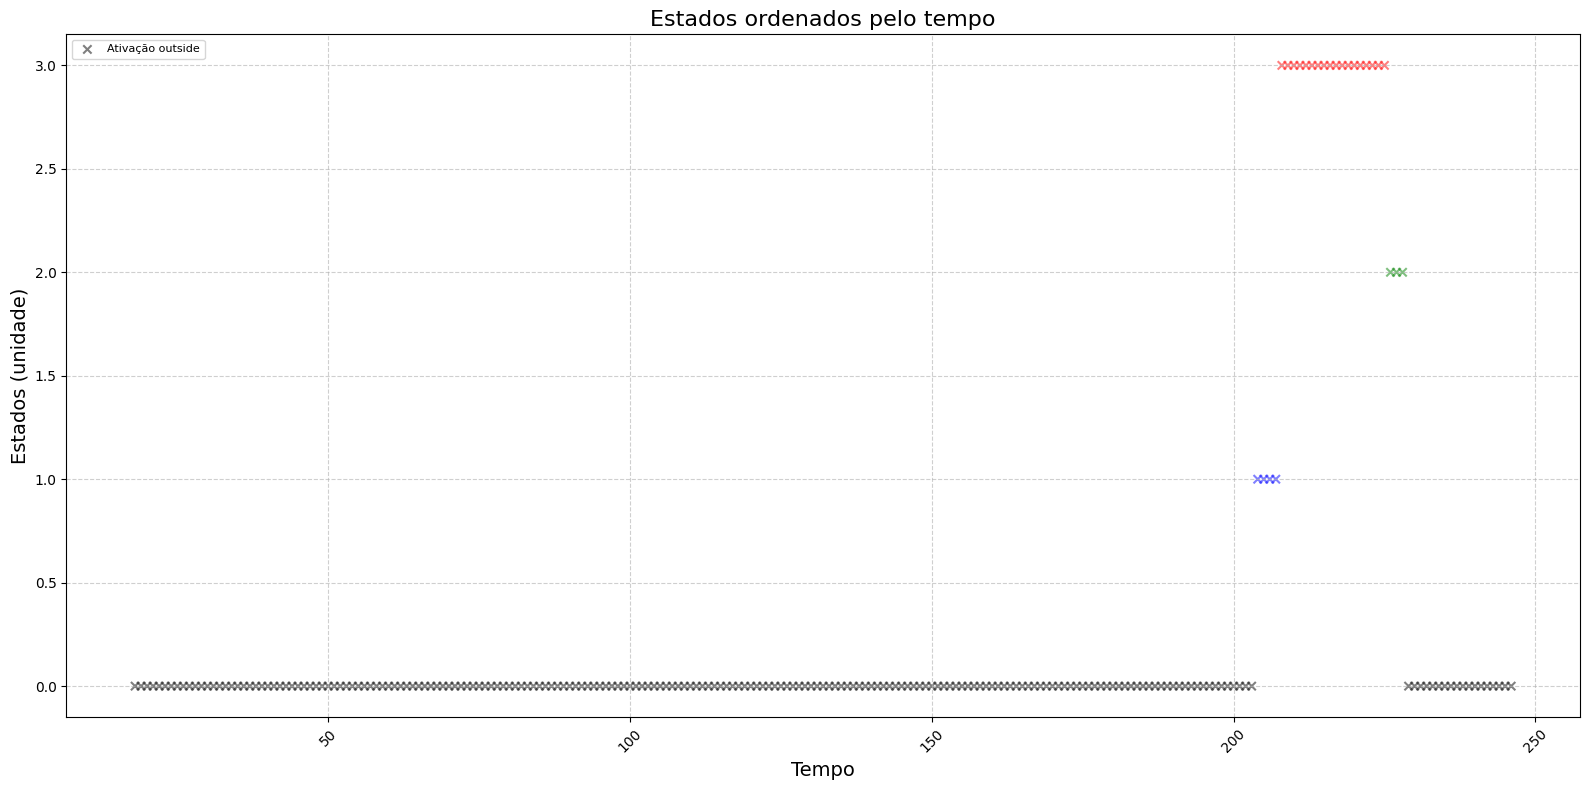

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  
    1: 'blue',   
    2: 'green',  
    3: 'red'  
}

colors = [color_map[state] for state in bin_data_comum['state']]

# Criar uma lista de cores baseada na coluna 'state'
#colors_inside = [color_map[state] for state in bin_data_comum['state_inside_sensor']]
#colors_outside = [color_map[state] for state in bin_data_comum['state_outside_sensor']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
#plt.scatter(bin_data_comum['id'], bin_data_comum['state_inside_sensor'], label='Ativação inside', alpha=0.5, marker='^')
#plt.scatter(bin_data_comum['id'], bin_data_comum['state_outside_sensor'], label='Ativação outside', alpha=0.5)
plt.scatter(bin_data_comum['id'], bin_data_comum['state'], c=colors, label='Ativação outside', alpha=0.5, marker="x")

# Adicionar as linhas de conexão
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['inside_smooth'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['outside_smooth'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Estados (unidade)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Estados ordenados pelo tempo', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
filename = f"statemap_{name}.png"

# Salvando o gráfico como PNG
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

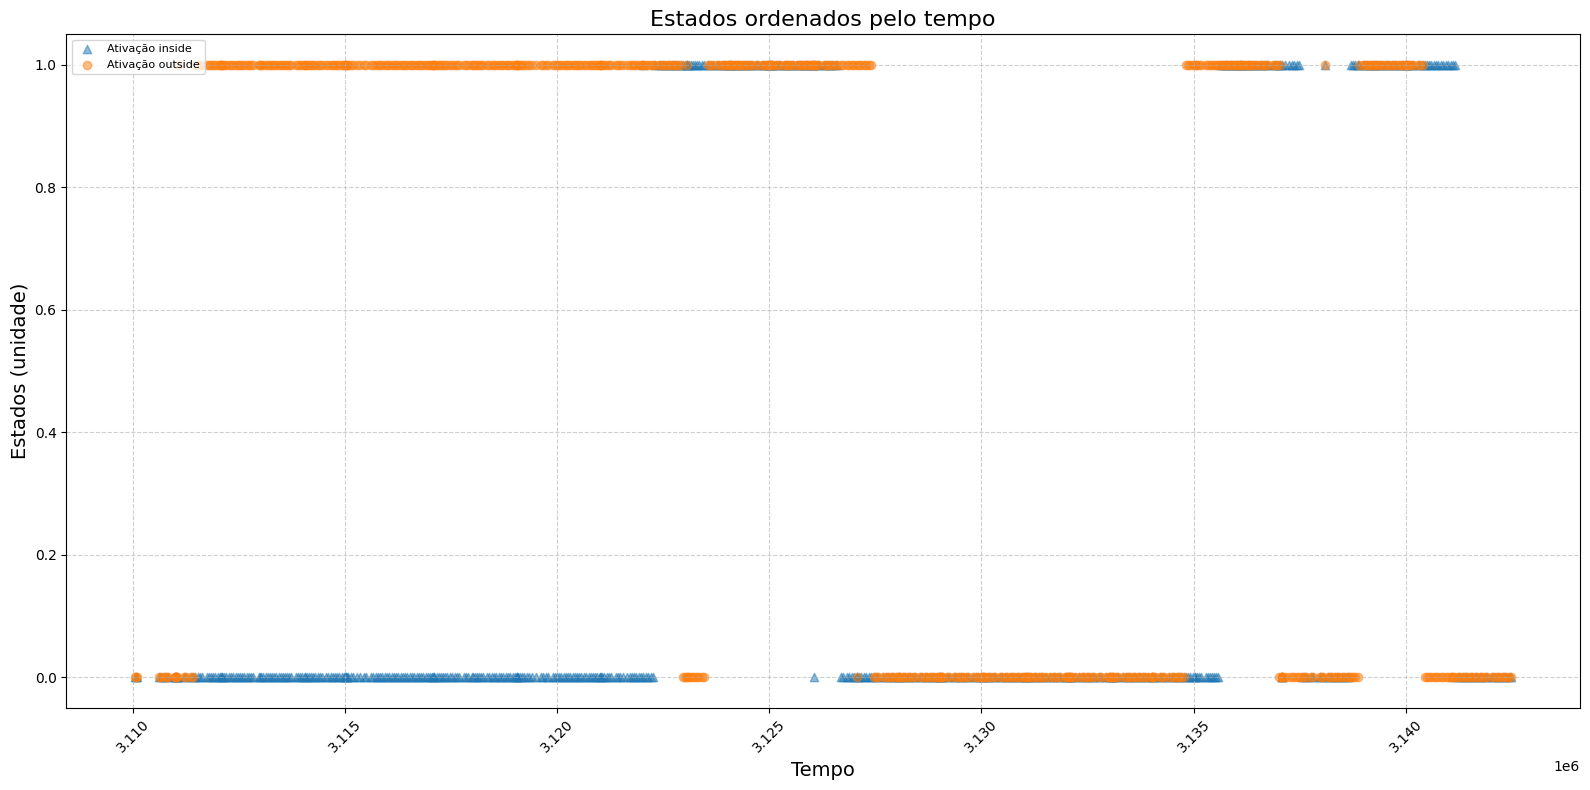

In [515]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
#colors_inside = [color_map[state] for state in bin_data_comum['state_inside_sensor']]
#colors_outside = [color_map[state] for state in bin_data_comum['state_outside_sensor']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data_comum['measured_at'], bin_data_comum['state_inside_sensor'], label='Ativação inside', alpha=0.5, marker='^')
plt.scatter(bin_data_comum['measured_at'], bin_data_comum['state_outside_sensor'], label='Ativação outside', alpha=0.5)
#plt.scatter(bin_data_comum['id'], bin_data_comum['state'], label='Ativação outside', alpha=0.5, marker="x")

# Adicionar as linhas de conexão
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['inside_smooth'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
#plt.plot(bin_data_comum['measured_at'], bin_data_comum['outside_smooth'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Estados (unidade)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Estados ordenados pelo tempo', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
plt.show()
#filename = f"grafico_comum_{name}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()

In [516]:

# Lista para armazenar os eventos
events = []

# Variável para armazenar o início do evento
event_start = None

# Percorrer o DataFrame
for i in range(len(bin_data_comum)):
    if bin_data_comum.loc[i, "state"] == 1:
        if event_start is None:
            # Início do evento
            event_start = i
            print(bin_data_comum.loc[i, "state_inside_sensor"])
            print(bin_data_comum.loc[i, "state_outside_sensor"])
    else:
        if event_start is not None:
            print(bin_data_comum.loc[i, "state_inside_sensor"])
            print(bin_data_comum.loc[i, "state_outside_sensor"])
            # Fim do evento
            start_inside = bin_data_comum.loc[event_start, "state_inside_sensor"]
            start_outside = bin_data_comum.loc[event_start, "state_outside_sensor"]
            end_inside = bin_data_comum.loc[i - 1, "state_inside_sensor"]
            end_outside = bin_data_comum.loc[i - 1, "state_outside_sensor"]

            if start_inside == 1 and start_outside == 0 and end_inside == 0 and end_outside == 1:
                events.append("Alguém saiu")
            elif start_inside == 0 and start_outside == 1 and end_inside == 1 and end_outside == 0:
                events.append("Alguém entrou")
            elif start_inside == 0 and start_outside == 1 and end_inside == 0 and end_outside == 1:
                events.append("Alguém desistiu de entrar")
            elif start_inside == 1 and start_outside == 0 and end_inside == 1 and end_outside == 0:
                events.append("Alguém desistiu de sair")

            # Resetar o evento
            event_start = None

# Exibir os eventos detectados
for event in events:
    print(event)

0
1
0
0
0
1
0
0
1
0
0
0
Alguém desistiu de entrar
Alguém entrou
Alguém desistiu de sair


### Plote com colorização por estado

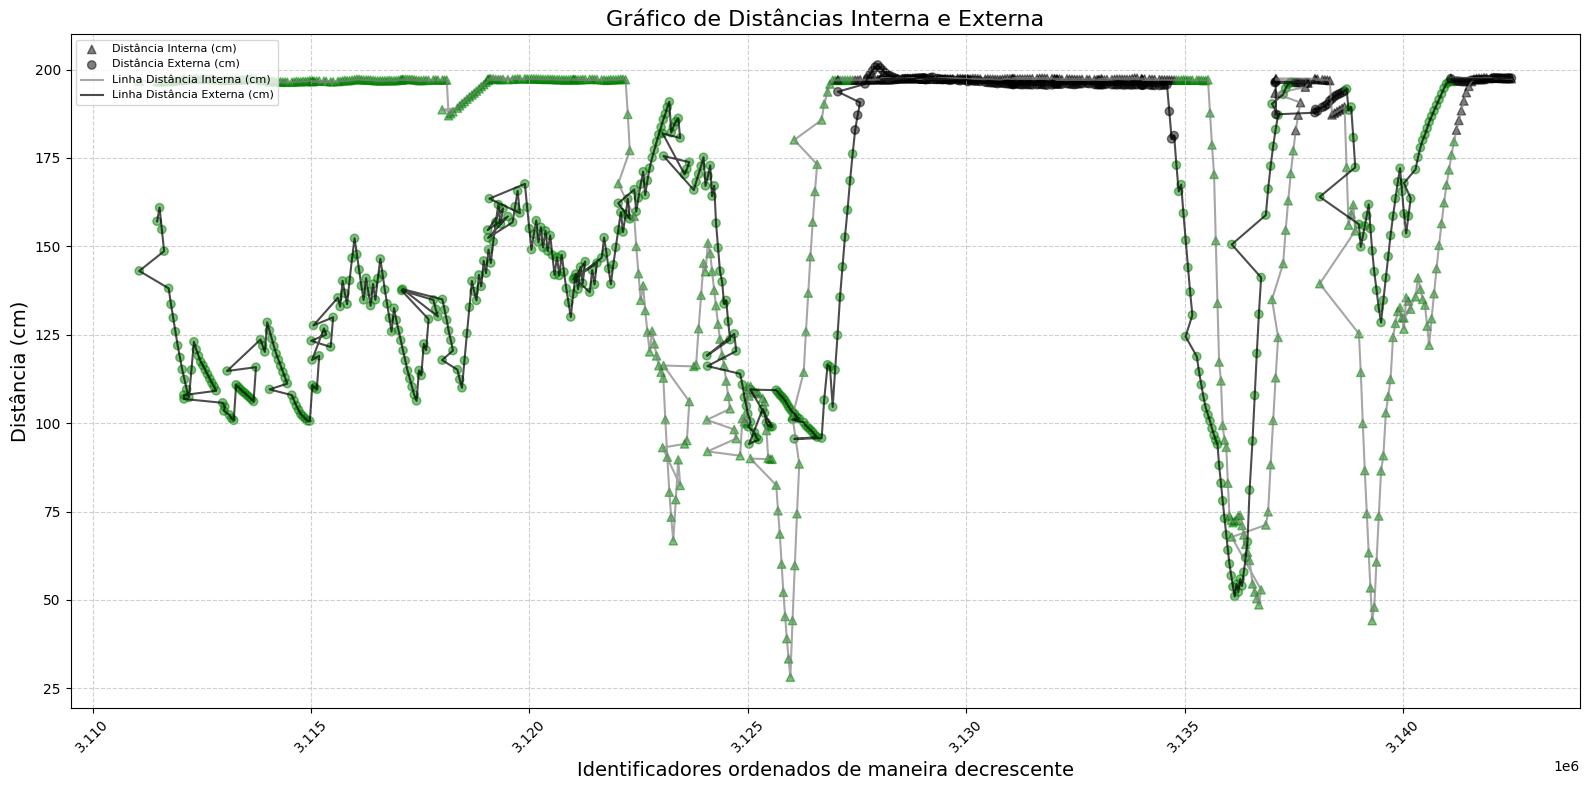

In [517]:
import matplotlib.pyplot as plt
import numpy as np

# Supondo que 'data' seja um DataFrame do pandas
# Exemplo de mapeamento de cores baseado no valor de 'state'
color_map = {
    0: 'black',  # state = 0 -> preto
    3: 'red',    # state = 3 -> vermelho
    2: 'blue',   # state = 2 -> azul
    1: 'green'  # state = 1 -> verde
}

# Criar uma lista de cores baseada na coluna 'state'
colors_inside = [color_map[state] for state in bin_data_comum['state']]
colors_outside = [color_map[state] for state in bin_data_comum['state']]

# Configurar o tamanho do gráfico
plt.figure(figsize=(16, 8))

# Adicionar os scatter plots com cores condicionais
plt.scatter(bin_data_comum['measured_at'], bin_data_comum['inside_smooth'], label='Distância Interna (cm)', alpha=0.5, marker='^', c=colors_inside)
plt.scatter(bin_data_comum['measured_at'], bin_data_comum['outside_smooth'], label='Distância Externa (cm)', alpha=0.5, c=colors_outside)

# Adicionar as linhas de conexão
plt.plot(bin_data_comum['measured_at'], bin_data_comum['inside_smooth'], linestyle='-', color='gray', alpha=0.7, label='Linha Distância Interna (cm)')
plt.plot(bin_data_comum['measured_at'], bin_data_comum['outside_smooth'], linestyle='-', color='black', alpha=0.7, label='Linha Distância Externa (cm)')

# Adicionar título e legendas
plt.xlabel('Identificadores ordenados de maneira decrescente', fontsize=14)
plt.ylabel('Distância (cm)', fontsize=14)
plt.legend(loc='upper left', fontsize=8)
plt.title('Gráfico de Distâncias Interna e Externa', fontsize=16)

# Adicionar grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar os rótulos do eixo X para evitar sobrecarga visual
plt.xticks(rotation=45, fontsize=10)  # Mostra um rótulo a cada 10 IDs

# Melhorar o layout geral
plt.tight_layout()

# Exibir o gráfico
plt.show()
#filename = f"grafico_comum_{name}.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()

### Tratamento para sub-dataframes

In [518]:
#Função parece ruim!
#Seria bom analisar mais afundo e conseguir enchergar os state 3.
#Armazeno os índices de todos os eventos que possues state = 3
state_3_indices = bin_data_comum[bin_data_comum['state'] == 3].index

def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Dicionário para armazenar os sub-DataFrames
sub_dataframes = {}

# Criar sub-DataFrames para cada índice onde state = 3
for i in range(1, len(state_3_indices)):
    #armazena o índice atual que possue state = 3
    current_idx = state_3_indices[i]
    #armazena current_idx - 1
    previous_idx = state_3_indices[i - 1]
    #não pegar os mesmos ranges
    if current_idx > previous_idx + 25:
        print(current_idx)
        # Aqui você pode adicionar o que deseja fazer quando a condição for verdadeira
        sub_dataframes[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data_comum, current_idx, window=25)


In [519]:
# Função para criar sub-DataFrames com base em um índice e uma janela
def get_sub_dataframe(data, index, window=25):
    start_idx = max(0, index - window)
    end_idx = min(len(data), index + window + 1)  # +1 para incluir o índice atual
    return data.iloc[start_idx:end_idx]

# Armazenar os índices de todos os eventos onde state != 0
non_zero_state_indices = bin_data_comum[bin_data_comum['state'] != 0].index

# Dicionário para armazenar os sub-DataFrames
sub_dataframes_1 = {}

# Criar sub-DataFrames para cada índice onde state != 0
for i, current_idx in enumerate(non_zero_state_indices):
    # Verificar se o índice atual não está muito próximo do anterior
    if i == 0 or current_idx > non_zero_state_indices[i - 1] + 25:
        print(f"Criando sub-DataFrame para o índice {current_idx}")
        sub_dataframes_1[f'sub_df_{current_idx}'] = get_sub_dataframe(bin_data_comum, current_idx, window=25)

# Exibir os sub-DataFrames criados
for key, sub_df in sub_dataframes_1.items():
    print(f"\n{key}:\n{sub_df}")

Criando sub-DataFrame para o índice 17
Criando sub-DataFrame para o índice 455

sub_df_17:
    id  distance_cm_inside  distance_cm_outside        device_code  \
0    1                 196                  196  F0:08:D1:D0:7B:84   
1    2                 196                  102  F0:08:D1:D0:7B:84   
2    3                 196                  196  F0:08:D1:D0:7B:84   
3    4                 196                  196  F0:08:D1:D0:7B:84   
4    5                 198                  196  F0:08:D1:D0:7B:84   
5    6                 198                  196  F0:08:D1:D0:7B:84   
6    7                 196                  100  F0:08:D1:D0:7B:84   
7    8                 196                  103  F0:08:D1:D0:7B:84   
8    9                 197                  196  F0:08:D1:D0:7B:84   
9   10                 196                  100  F0:08:D1:D0:7B:84   
10  11                 196                  197  F0:08:D1:D0:7B:84   
11  12                 198                  102  F0:08:D1:D0:7B:84   

In [520]:
print(state_3_indices)

Index([], dtype='int64')


In [521]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}
state_map = {0: 'Inativo', 1: 'Ativ. externa', 2: 'Ativ. interna', 3: 'Ativ. dupla'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'{state_map[state]}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
#plt.show()
filename = f"grafico_comum_sub_dataframes.png"

# Salvando o gráfico como PNG
#plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close()


2


In [522]:
#Estado da linha anterior
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
#Percorrendo dicionário de eventos:
count = 0
for key, df in sub_dataframes_1.items():
  print(key)
  previous_state = 0
  state_machine = 0
  # Convertendo a coluna 'measured_at' para datetime
  #df['measured_at'] = pd.to_datetime(df['measured_at'])
  #Percorrendo cada linha de cada evento
  for index, row in df.iterrows():
    #print(row['state'], state_machine)
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count =+ 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count =- 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
  print("")
print("Quantidade de pessoas:", end=" ")
print(count)



sub_df_17

sub_df_455

Quantidade de pessoas: 0


2


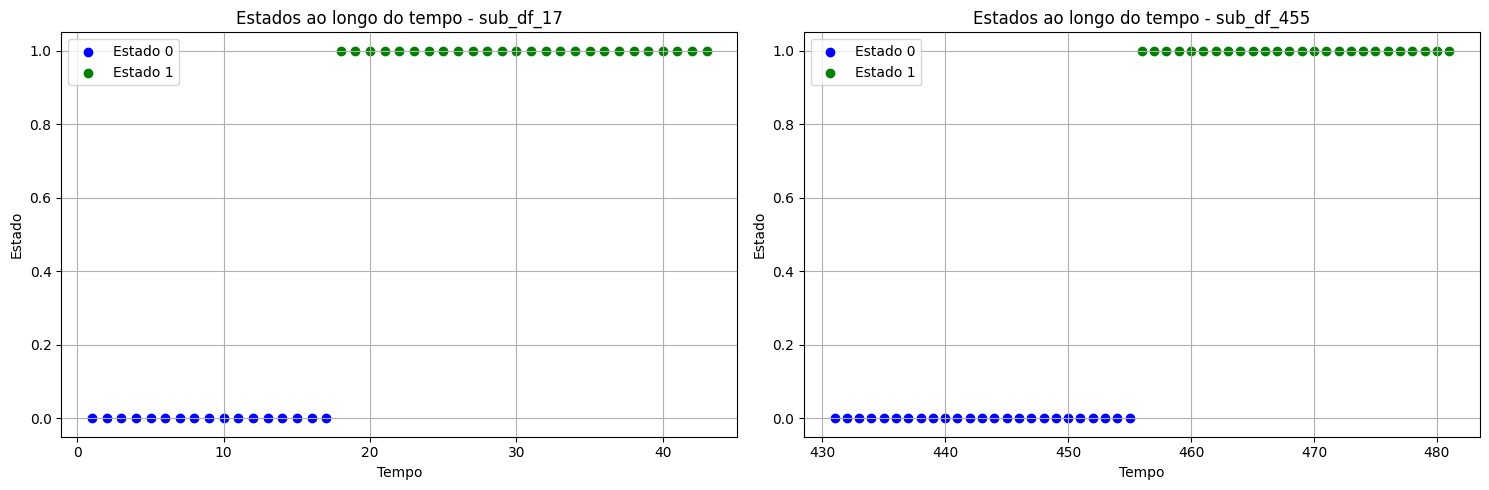

In [523]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Configuração do mapa de cores
color_map = {0: 'blue', 1: 'green', 2: 'red', 3: 'purple'}

# Quantidade de DataFrames
num_dfs = len(sub_dataframes_1)
print(len(sub_dataframes_1))
cols = 2  # Número de colunas na grade de subplots
rows = (num_dfs + cols - 1) // cols  # Número de linhas calculadas para acomodar todos os DataFrames

# Criando uma figura grande para acomodar todos os subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axs = axs.flatten()  # Transforma a matriz de axs em um array linear para facilitar o acesso

# Iterando sobre cada subframe dentro do dicionário de dataframes
for idx, (key, df) in enumerate(sub_dataframes_1.items()):
    # Convertendo a coluna 'measured_at' para datetime

    # Plotando dados para cada estado único no subplot correspondente
    for state in df['state'].unique():
        subset = df[df['state'] == state]
        axs[idx].scatter(subset['id'], subset['state'], color=color_map[state], label=f'Estado {state}')

    # Formatando o eixo X para mostrar datas
    #axs[idx].xaxis.set_major_formatter(DateFormatter('%M:%S'))
    #axs[idx].figure.autofmt_xdate()  # Auto-formata as datas para evitar sobreposição

    # Adicionando título e legendas
    axs[idx].set_title(f'Estados ao longo do tempo - {key}')
    axs[idx].set_xlabel('Tempo')
    axs[idx].set_ylabel('Estado')
    axs[idx].legend()
    axs[idx].grid(True)

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

In [524]:
#Estado da linha anterior
previous_state = 0
count = 0
#Máquina de estados
  #0 = sem excitação
  #1 = entrando
  #2 = saindo
state_machine = 0
for index, row in bin_data_comum.iterrows():
    #Condição para iniciar a máquina de estados
    if(row['state'] == 3 and state_machine == 0):
      print("Evento de interesse:", end=" ")
      if(previous_state == 1):
        print("Alguém está entrando...", end=" ")
        state_machine = 1
      if(previous_state == 2):
        print("Alguém está saindo...", end=" ")
        state_machine = 2
    else:
    #Condição redundante para os dois estados(3,3)
    #Não precisa existir
    #if(previous_state == 3 and row['state'] == 3):
      #print("Alguém continua tentando entrar/sair...", end=" ")
      #state_machine = state_machine
    #Possíveis caminhos para o estado de entrada
      if(state_machine == 1):
        if(previous_state == 2 and row['state'] == 0):
          print("Alguém entrou")
          count = count + 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 1):
          print("A pessoa desistiu de entrar")
          state_machine = 0
        else:
          print("Alguém continua tentando entrar...", end=" ")
        #A máquina de estados nao varia
      #Possíveis caminhos para o estado de saída
      if(state_machine == 2):
        if(previous_state == 1 and row['state'] == 0):
          print("Alguém saiu")
          count = count - 1
          state_machine = 0
        elif(row['state'] == 0 or row['state'] == 2):
          print("A pessoa desistiu de sair")
          state_machine = 0
        else:
          print("Alguém continua tentando sair...", end=" ")
        #A máquina de estados nao varia
    previous_state = row['state']
print(count)  

0


In [525]:
bin_data_comum

,id,distance_cm_inside,distance_cm_outside,device_code,measured_at,errors,minute,second,millisecond,inside_smooth,outside_smooth,inside_smooth_classification,outside_smooth_classification,state_inside_sensor,state_outside_sensor,state
0,1,196,196,F0:08:D1:D0:7B:84,3110056,0,51,50,56,NaN,NaN,Nada,Nada,0,0,0
1,2,196,102,F0:08:D1:D0:7B:84,3110612,0,51,50,612,NaN,NaN,Nada,Nada,0,0,0
2,3,196,196,F0:08:D1:D0:7B:84,3110669,0,51,50,669,NaN,NaN,Nada,Nada,0,0,0
3,4,196,196,F0:08:D1:D0:7B:84,3110726,0,51,50,726,NaN,NaN,Nada,Nada,0,0,0
4,5,198,196,F0:08:D1:D0:7B:84,3110783,0,51,50,783,NaN,NaN,Nada,Nada,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,600,197,197,F0:08:D1:D0:7B:84,3142255,0,52,22,255,197.520468,197.555556,Nada,Nada,0,0,0
600,601,197,197,F0:08:D1:D0:7B:84,3142312,0,52,22,312,197.467836,197.520468,Nada,Nada,0,0,0
601,602,197,198,F0:08:D1:D0:7B:84,3142369,0,52,22,369,197.415205,197.584795,Nada,Nada,0,0,0
602,603,198,198,F0:08:D1:D0:7B:84,3142426,0,52,22,426,197.467836,197.637427,Nada,Nada,0,0,0
